In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
import statsmodels.api as sm

# Dataset description

A dataset from one of the most popular football computer games, FIFA 20, containing information about players and their various characteristics.

The dataset contains 18,278 players with 104 different attributes.

In [3]:
csv_path = r"C:\Users\user\.cache\kagglehub\datasets\stefanoleone992\fifa-20-complete-player-dataset\versions\1\players_20.csv"

df = pd.read_csv(csv_path, low_memory=False)
print(df.shape)
df.head()

(18278, 104)


,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


# Primary data analysis

## Dataset features type

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


In [5]:
dtypes_table = (
    df.dtypes
      .astype(str)
      .reset_index()
      .rename(columns={"index": "column", 0: "pandas_dtype"})
      .sort_values(["pandas_dtype", "column"])
)

display(dtypes_table)

,column,pandas_dtype
28,contract_valid_until,float64
35,defending,float64
34,dribbling,float64
37,gk_diving,float64
38,gk_handling,float64
...,...,...
98,rwb,object
2,short_name,object
79,st,object
24,team_position,object


## Описательная статистика

In [6]:
df.describe()

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


## Player's position

Based on the team_position feature (a player's position in the team), we will create a role feature that will indicate the player's position (goalkeeper, defender, midfielder, forward). Then, using various histograms, we will look at their distribution.

In [7]:
pos = df["team_position"].astype(str).str.upper().str.strip()

df["role"] = np.select(
    [
        pos.eq("GK"),                                     # goalkeeper
        pos.str.contains("B", na=False),                  # defender
        pos.str.contains("M", na=False),                  # midfielder
        pos.str.contains("F", na=False) | pos.isin(["ST", "LW", "RW"])  # forward
    ],
    ["goalkeeper", "defender", "midfielder", "forward"],
    default=np.nan
)


display(df[["team_position", "role"]].head(20))
display(df["role"].value_counts())

,team_position,role
0,RW,forward
1,LW,forward
2,CAM,midfielder
3,GK,goalkeeper
4,LW,forward
5,RCM,midfielder
6,GK,goalkeeper
7,LCB,defender
8,RCM,midfielder
9,RW,forward


role
defender      10476
nan            3588
midfielder     2719
forward         833
goalkeeper      662
Name: count, dtype: int64

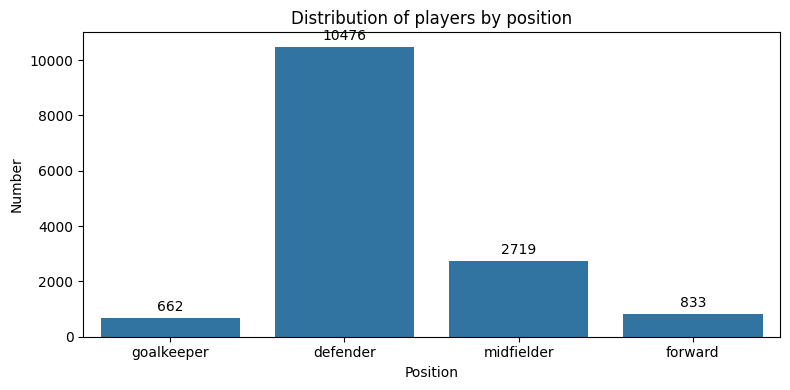

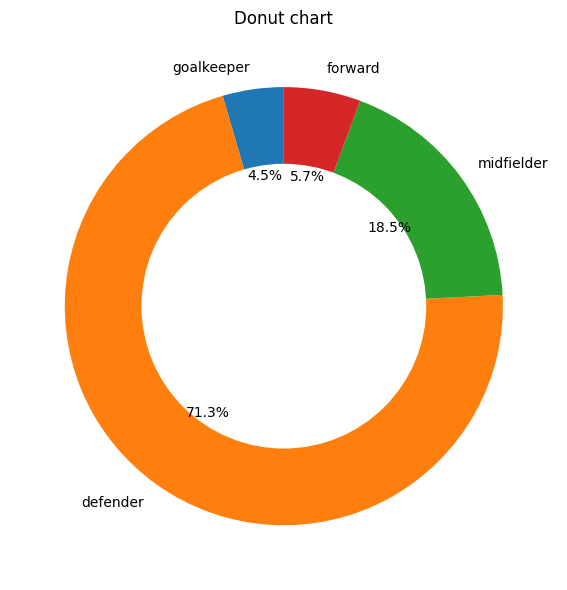

In [8]:
role_order = ["goalkeeper", "defender", "midfielder", "forward"]

df["role"] = pd.Categorical(df["role"], categories=role_order, ordered=True)

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="role", order=role_order)
ax.set_title("Distribution of players by position")
ax.set_xlabel("Position")
ax.set_ylabel("Number")

# column headings
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10, xytext=(0, 3),
                textcoords="offset points")
plt.tight_layout()
plt.show()


role_counts = df["role"].value_counts(dropna=False).reindex(role_order)
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    role_counts.values,
    labels=role_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90
)

centre_circle = plt.Circle((0, 0), 0.65, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Donut chart")
plt.tight_layout()
plt.show()

In [9]:
role_counts_df = (
    df["role"].value_counts(dropna=False)
      .rename_axis("role")
      .reset_index(name="count")
)

fig = px.bar(
    role_counts_df,
    x="role",
    y="count",
    title="Position: interactive diagram",
    text="count"
)
fig.update_traces(textposition="outside")
fig.update_layout(xaxis_title="Position", yaxis_title="Number")
fig.show()


## Dependent features

### Main features of players and their common rating

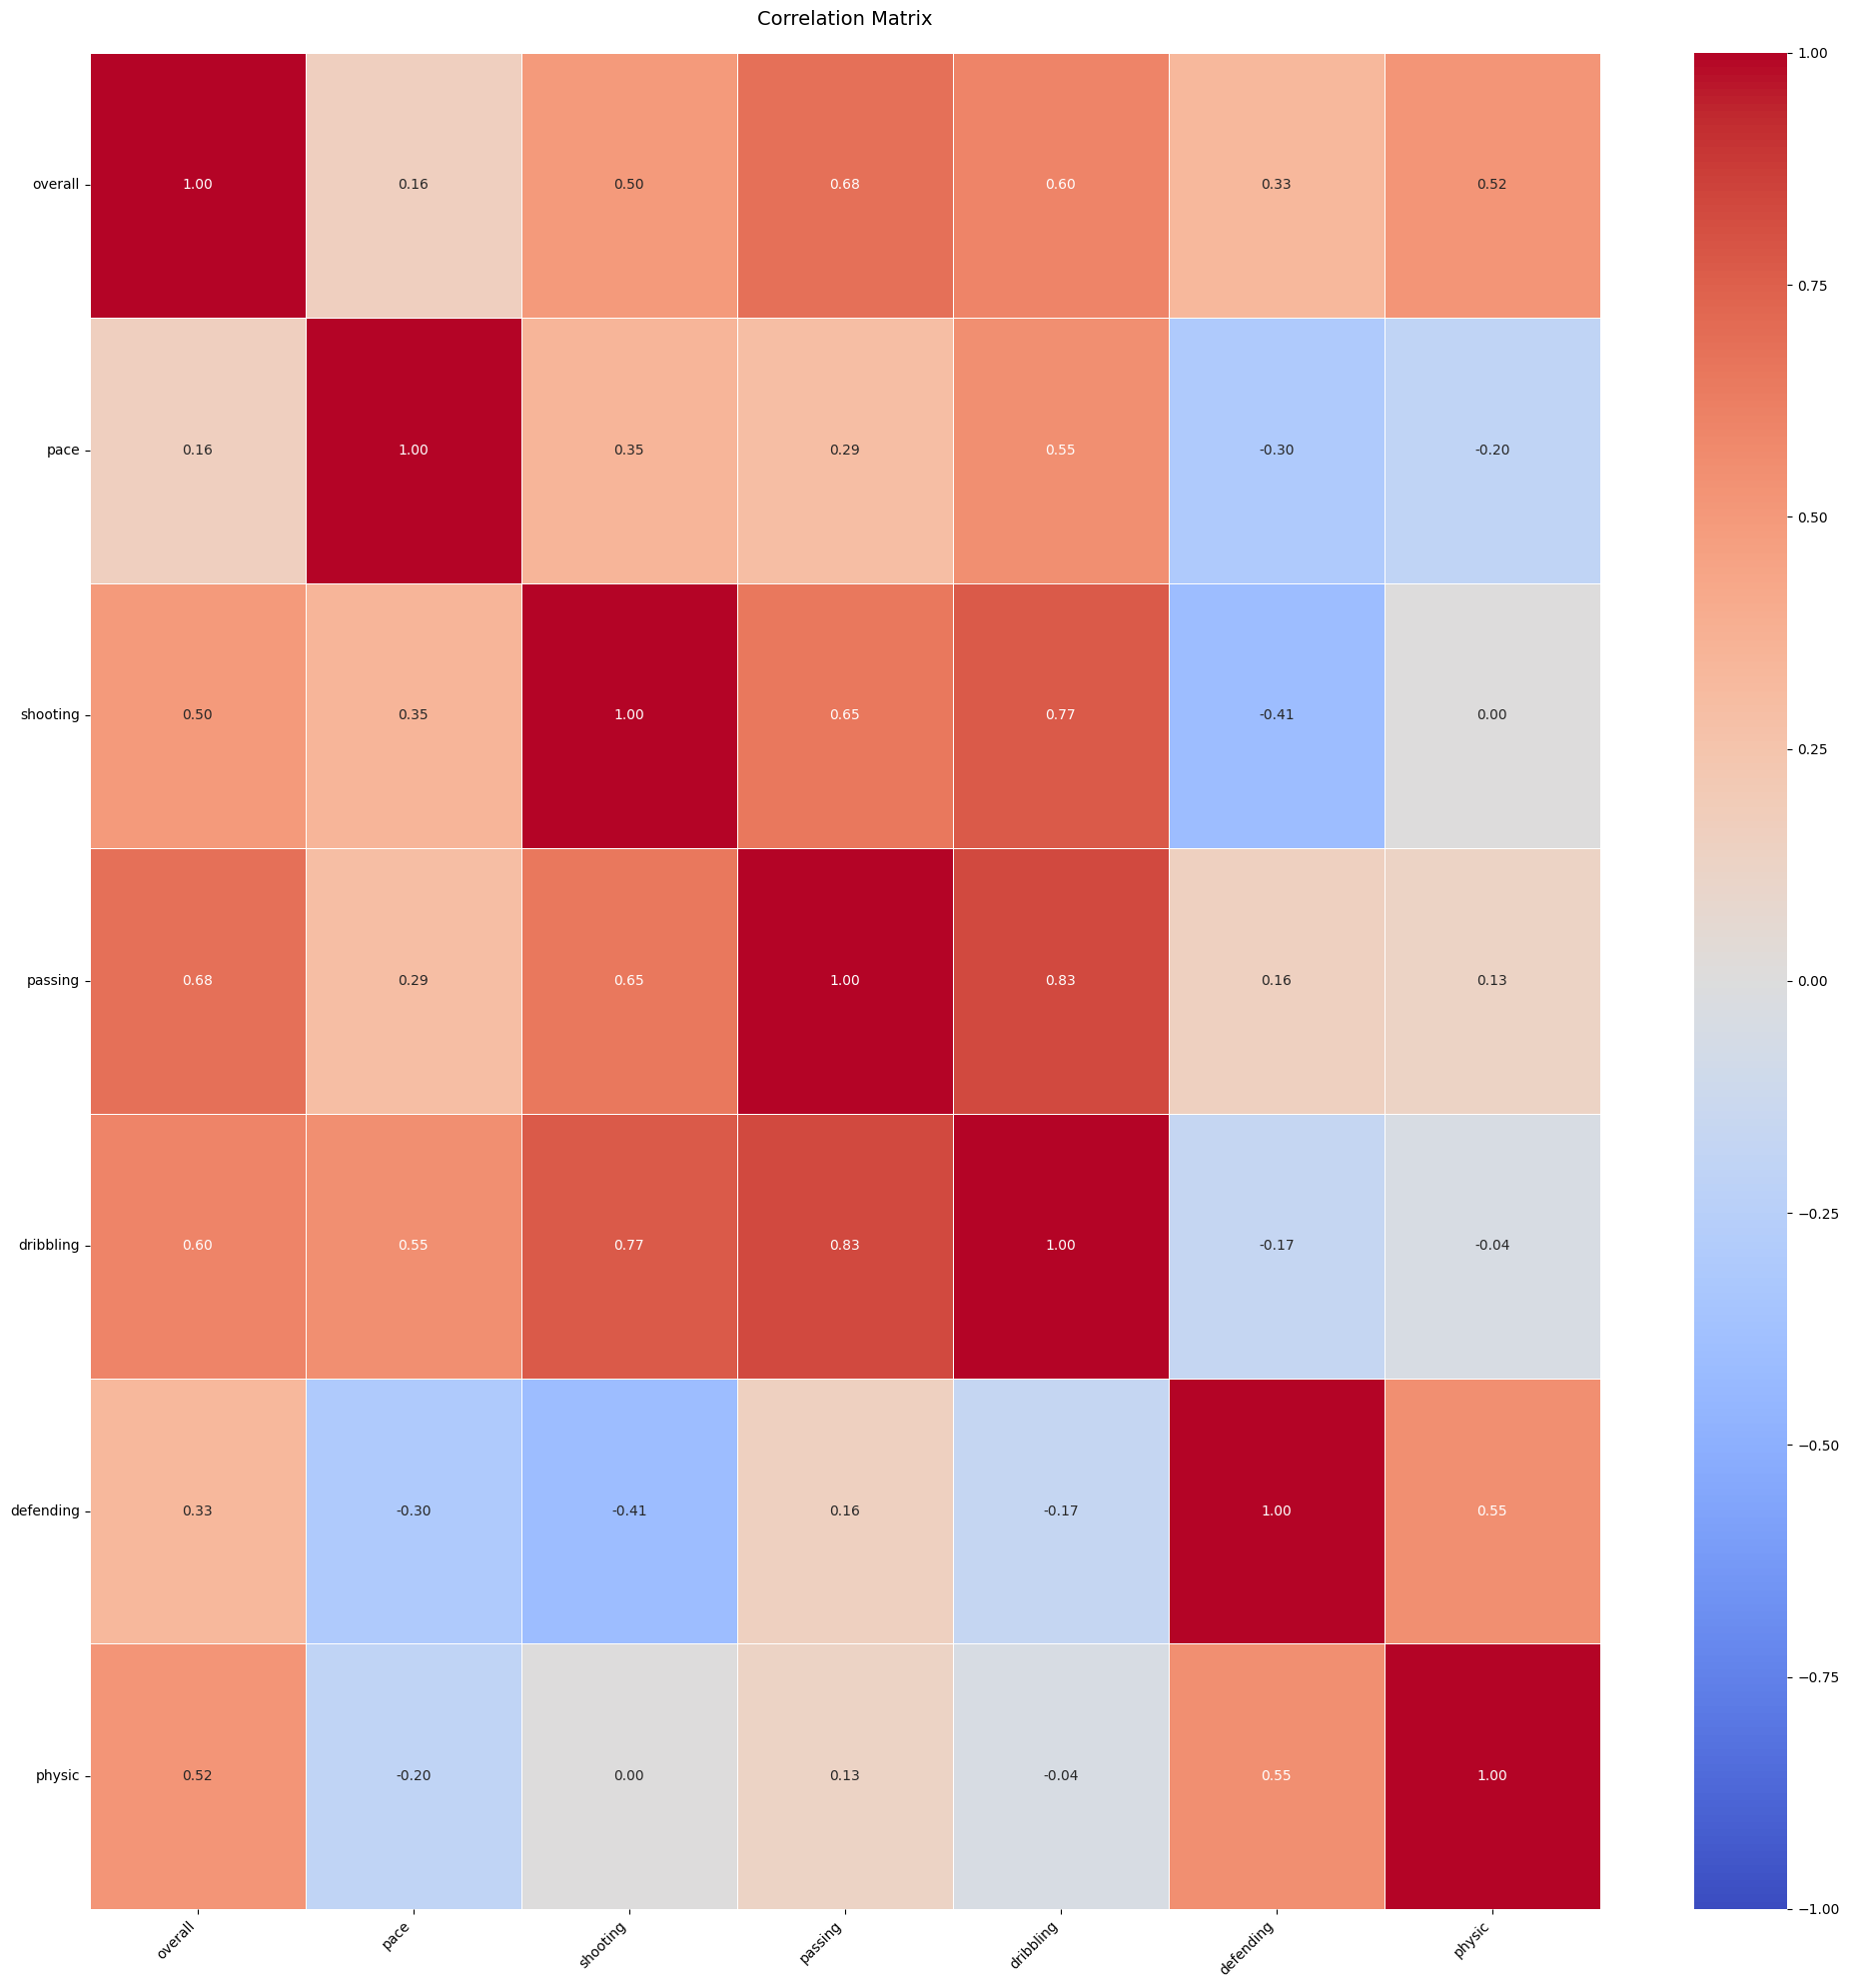

In [10]:
cols = ['overall', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

corr_matrix = df[cols].corr()

plt.figure(figsize=(20, 20))

heatmap = sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 10}
)

heatmap.set_xticklabels(
    heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=10
)
heatmap.set_yticklabels(
    heatmap.get_yticklabels(),
    rotation=0,
    fontsize=10
)

plt.title("Correlation Matrix", pad=20, fontsize=14)
plt.tight_layout()
plt.show()

There are fairly strong correlations between the features, especially between dribbling and passing, and dribbling and shooting.

### Player potential and age

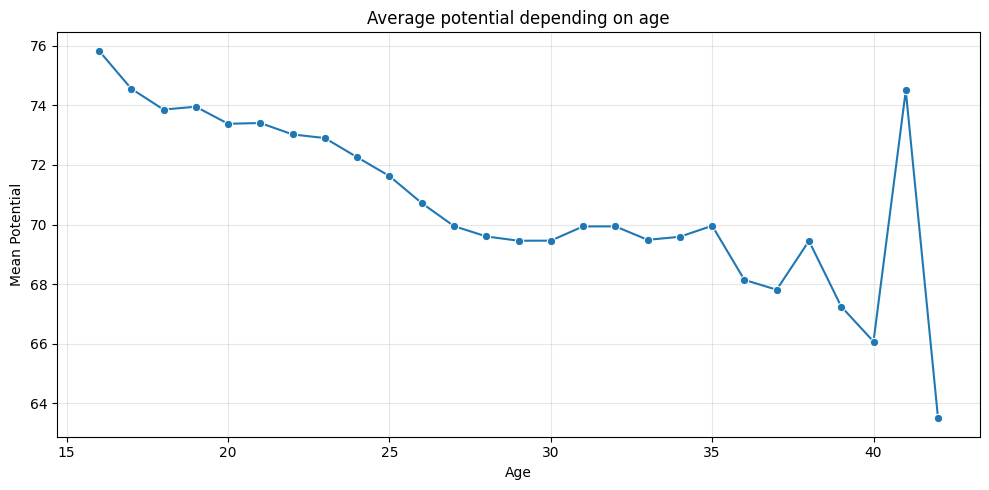

In [11]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["potential"] = pd.to_numeric(df["potential"], errors="coerce")

tmp = (df[["age", "potential"]]
       .dropna()
       .groupby("age", as_index=False)["potential"]
       .mean()
       .sort_values("age"))

plt.figure(figsize=(10, 5))
sns.lineplot(data=tmp, x="age", y="potential", marker="o")
plt.title("Average potential depending on age")
plt.xlabel("Age")
plt.ylabel("Mean Potential")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

With the exception of one outlier at the age of 41-42, it can be observed that the younger the players are, the higher their average potential is.

## Distribution of categorical features

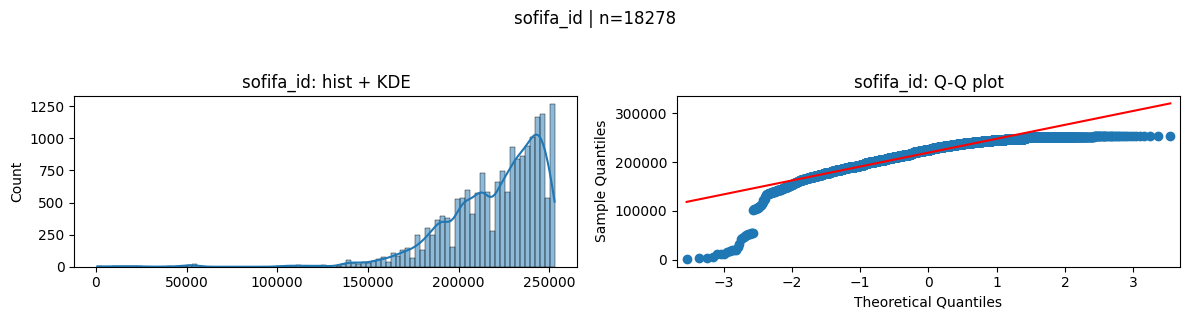

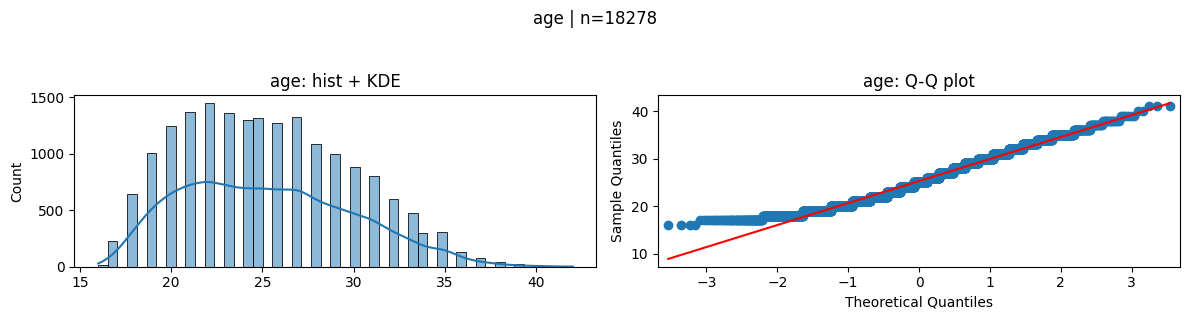

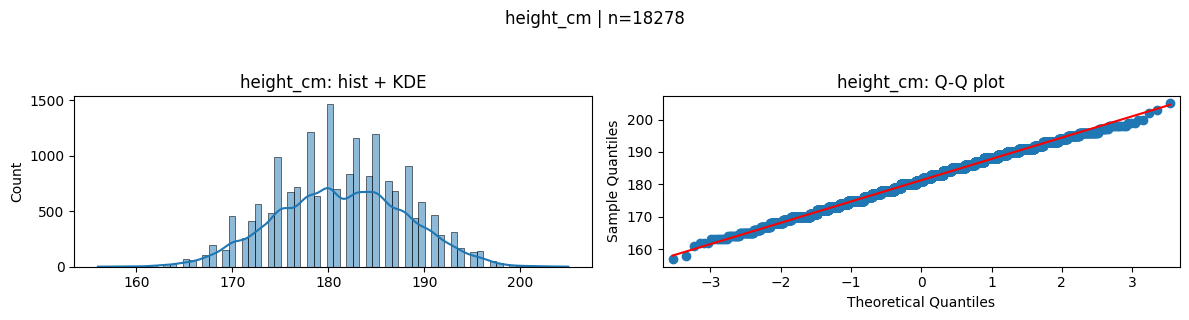

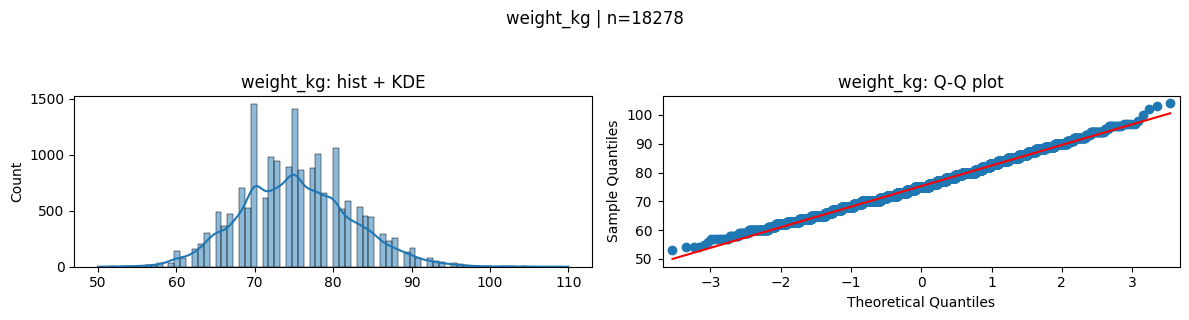

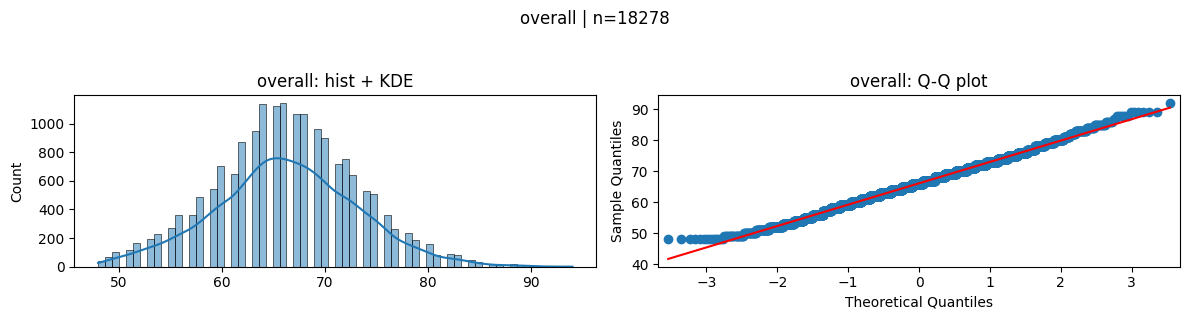

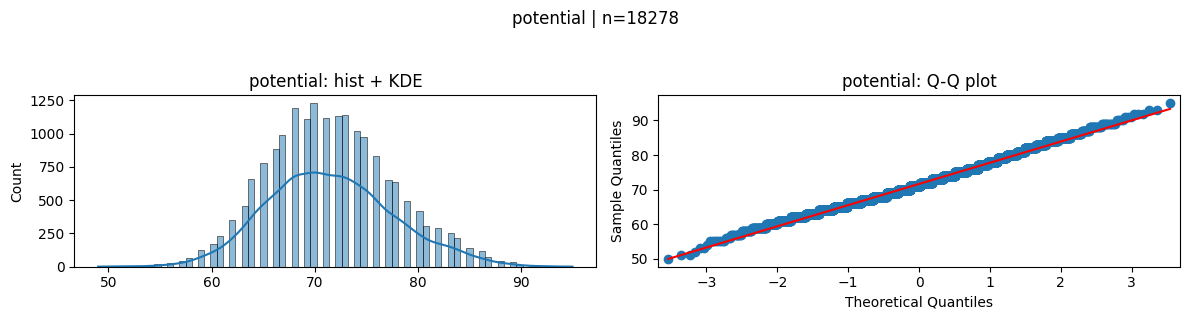

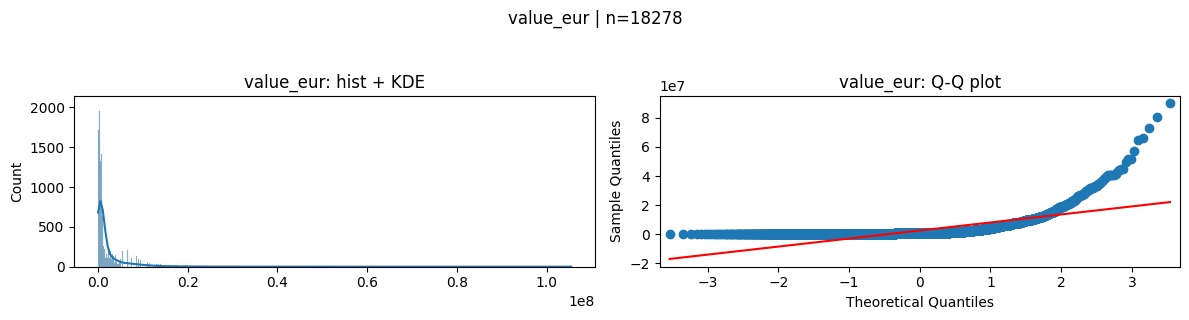

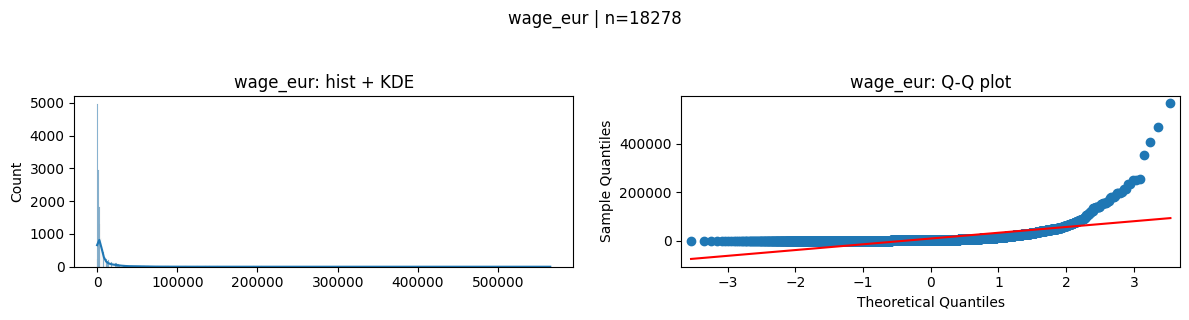

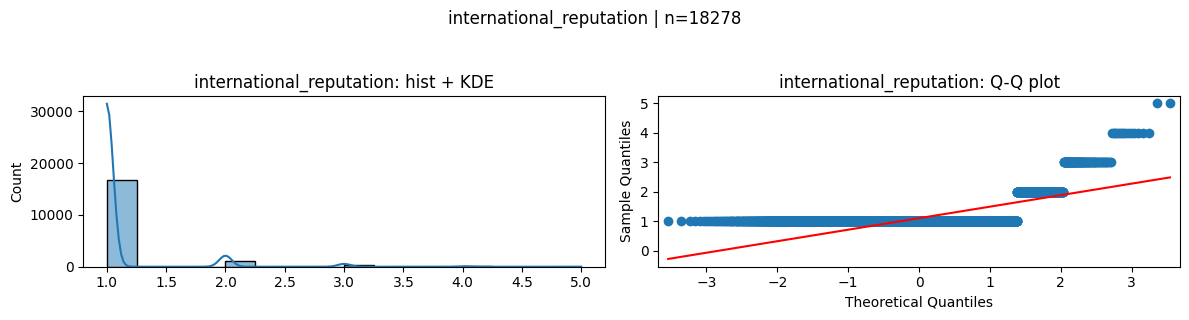

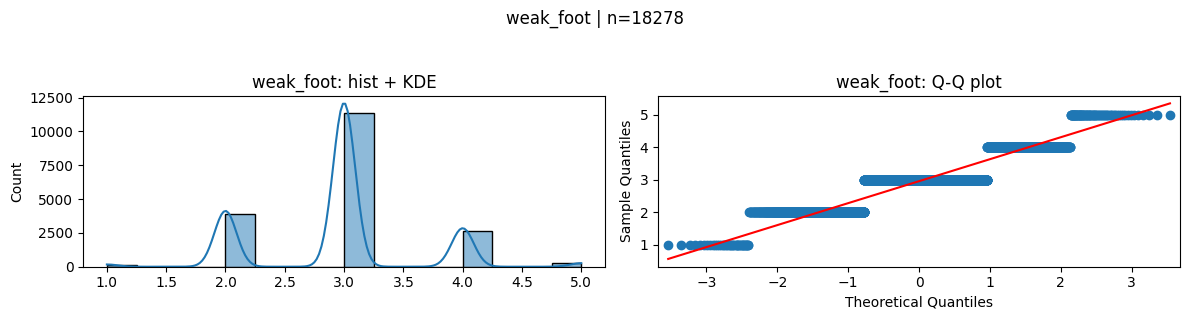

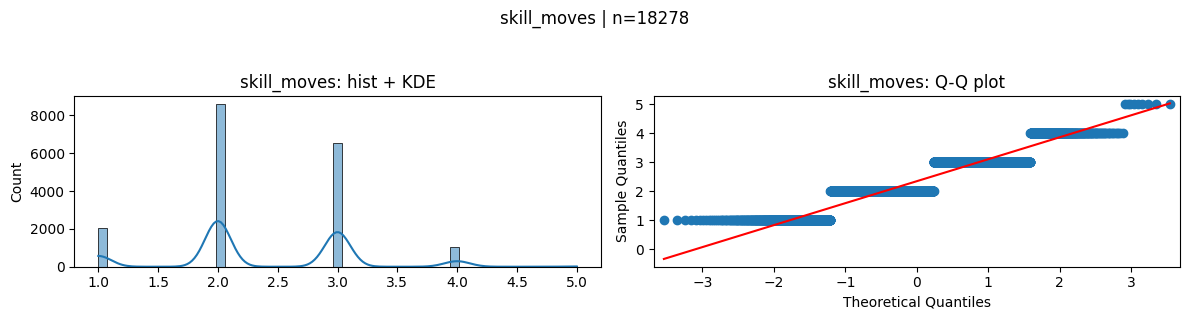

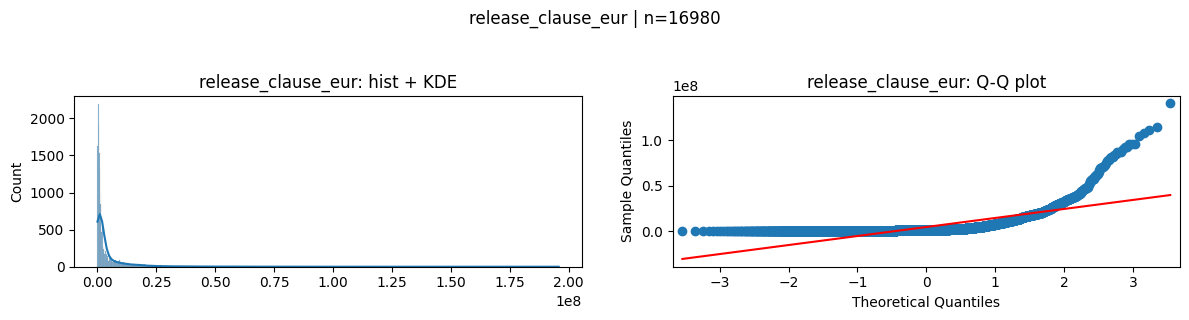

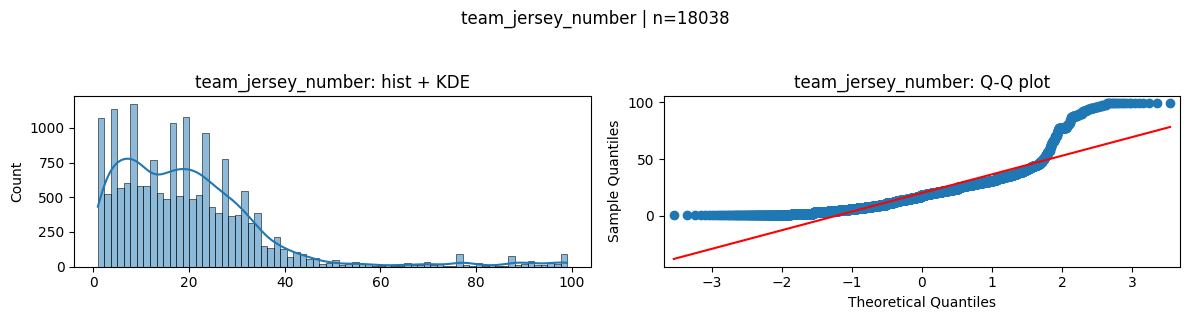

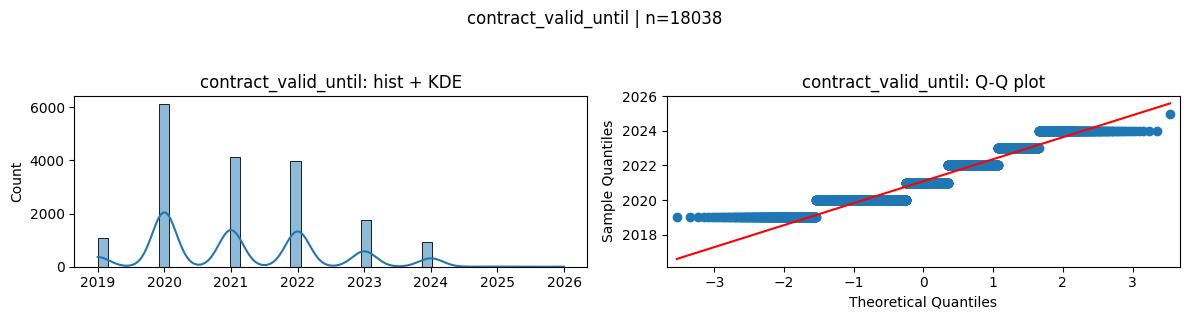

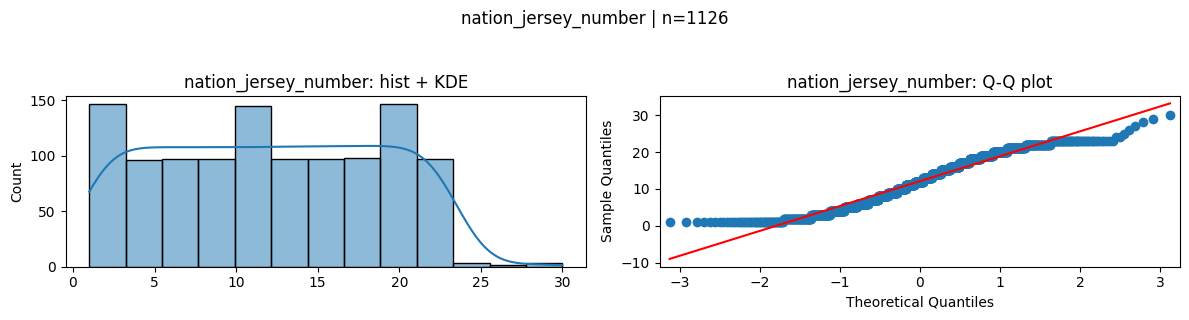

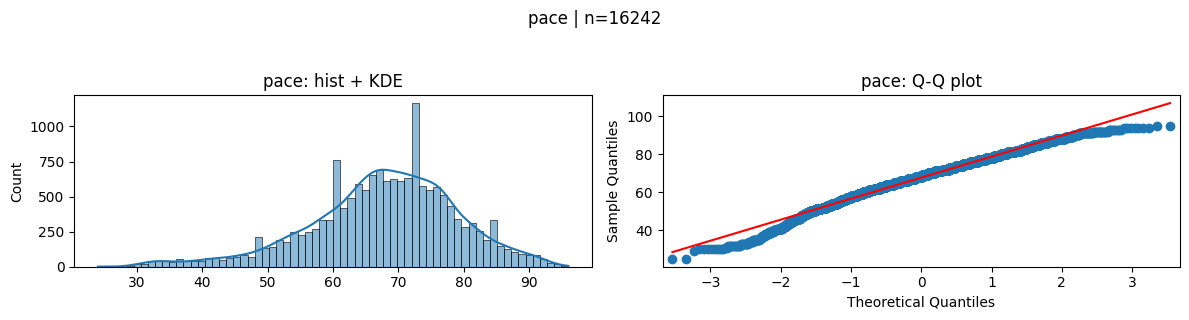

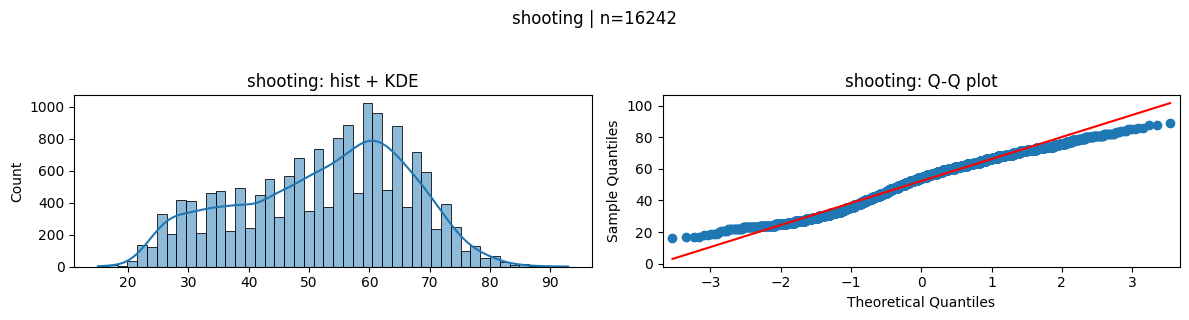

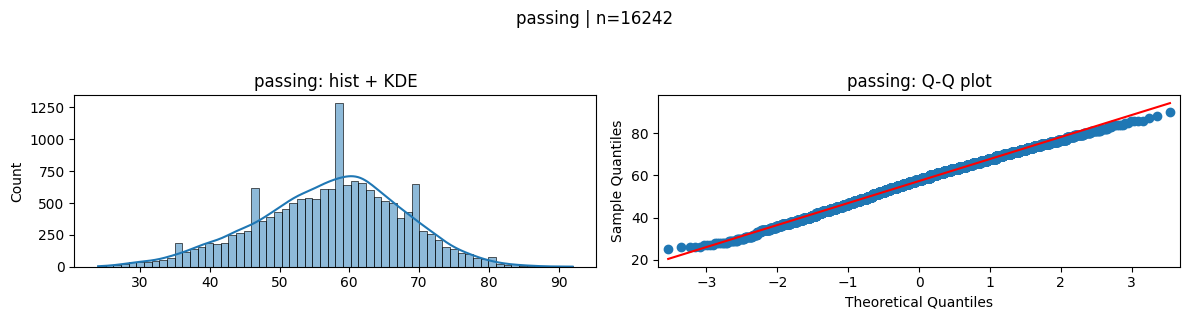

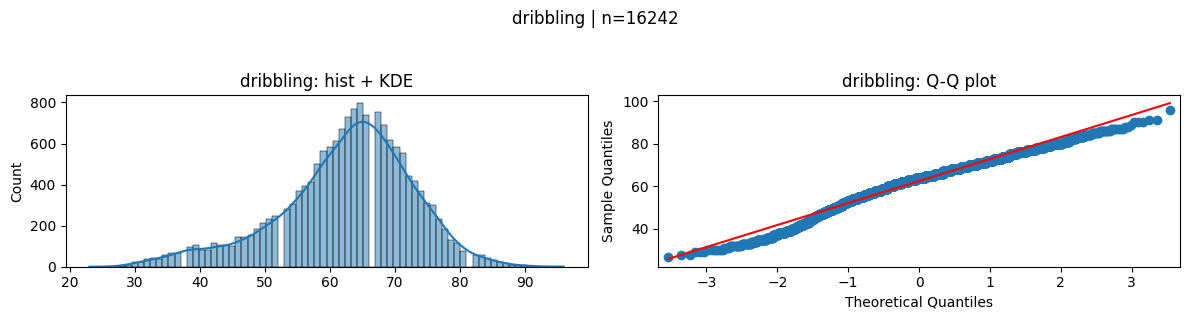

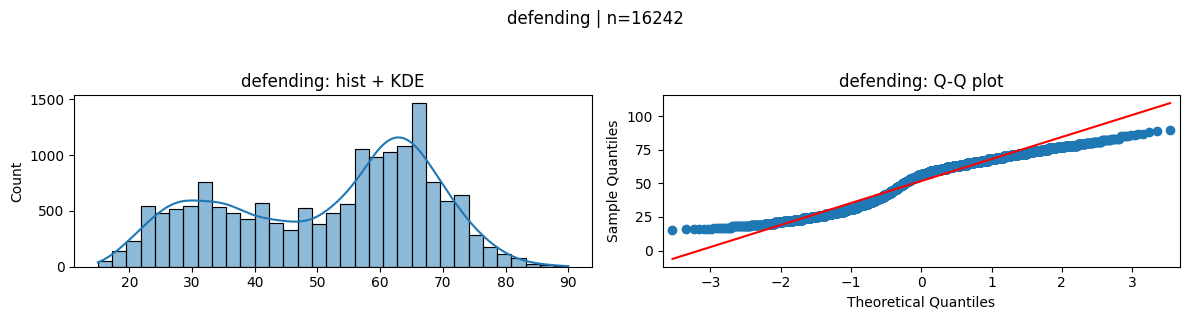

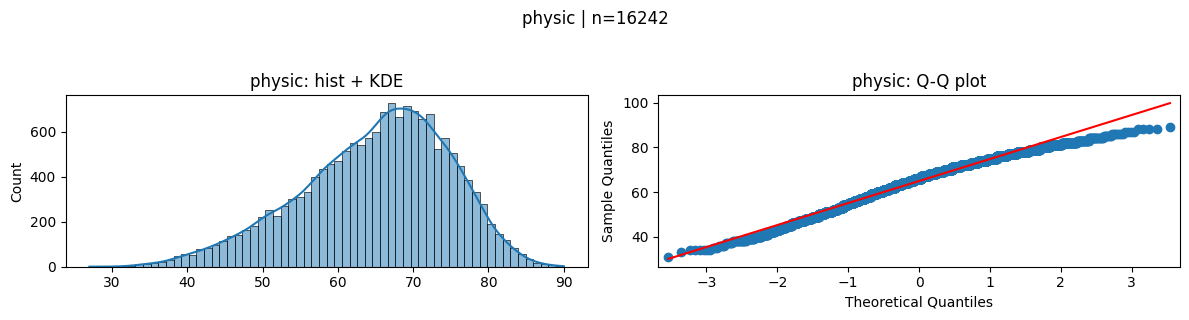

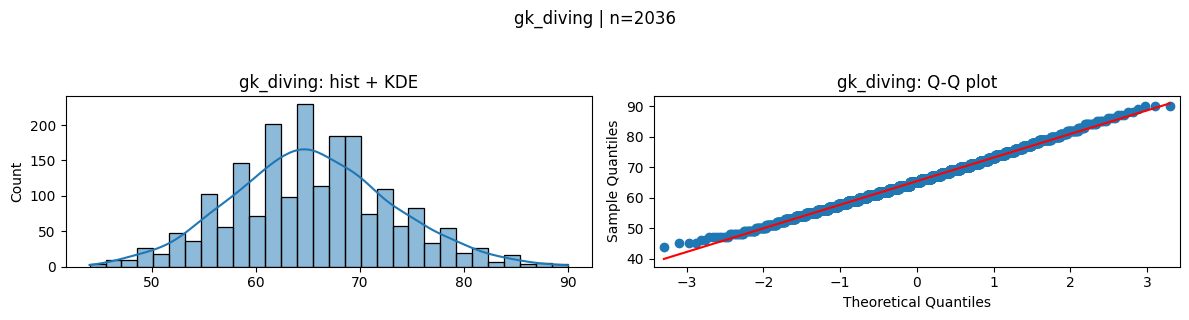

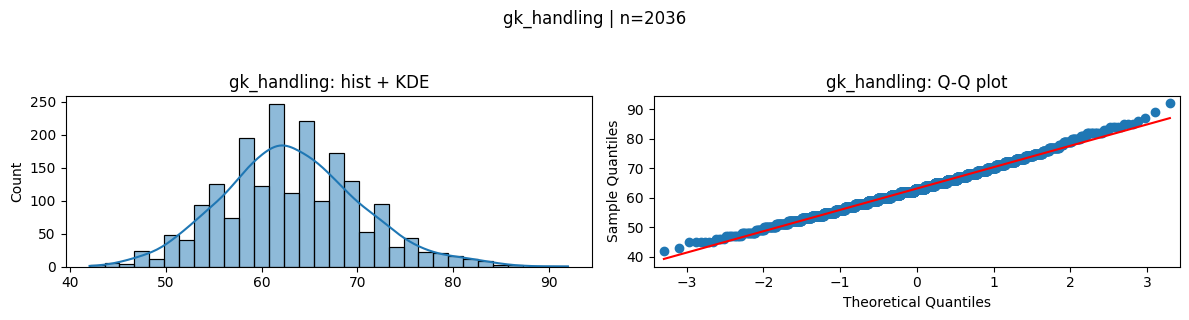

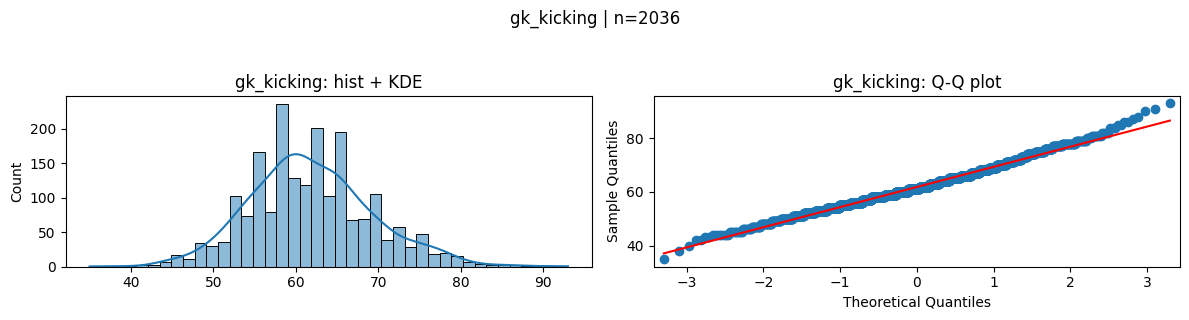

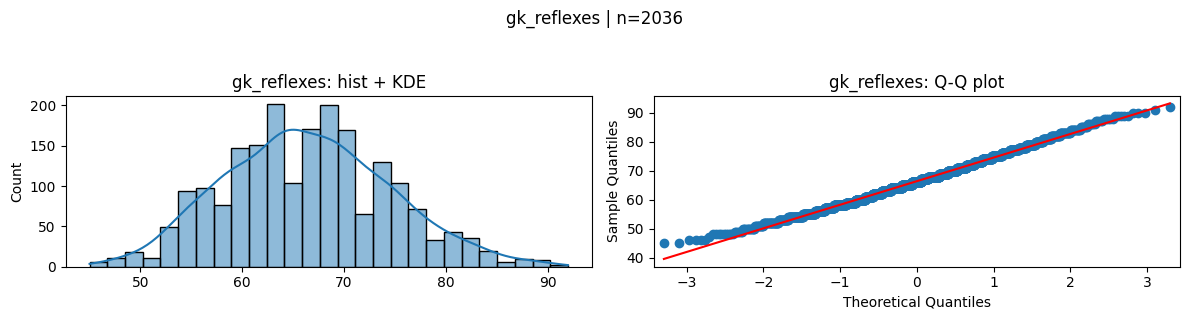

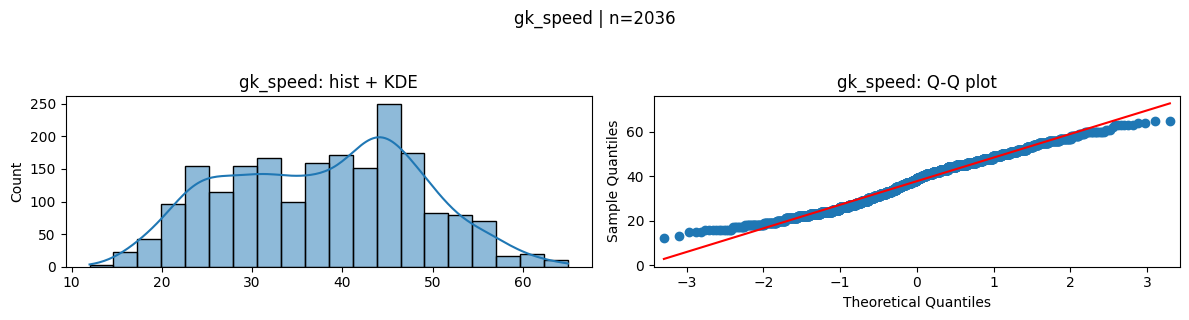

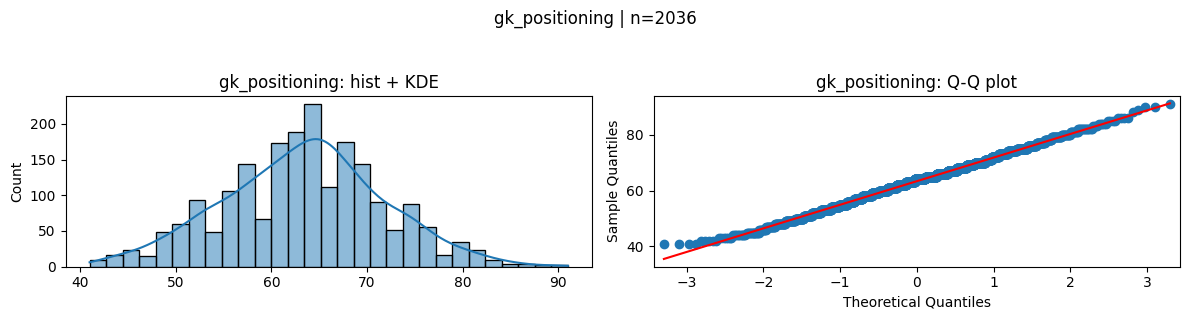

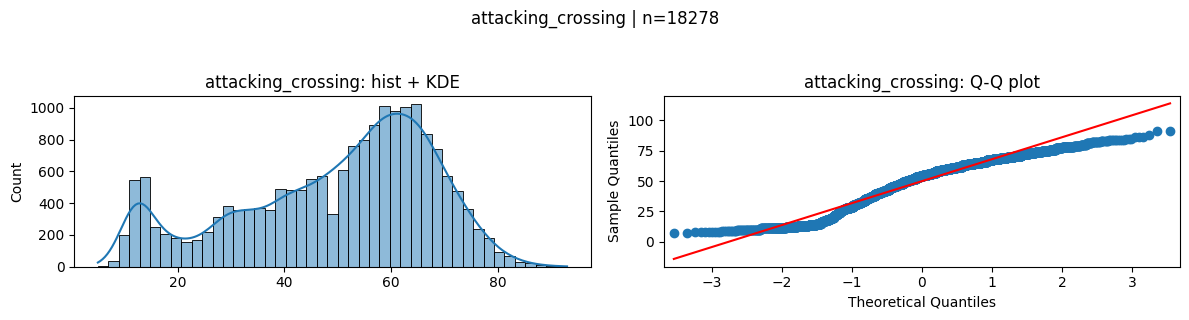

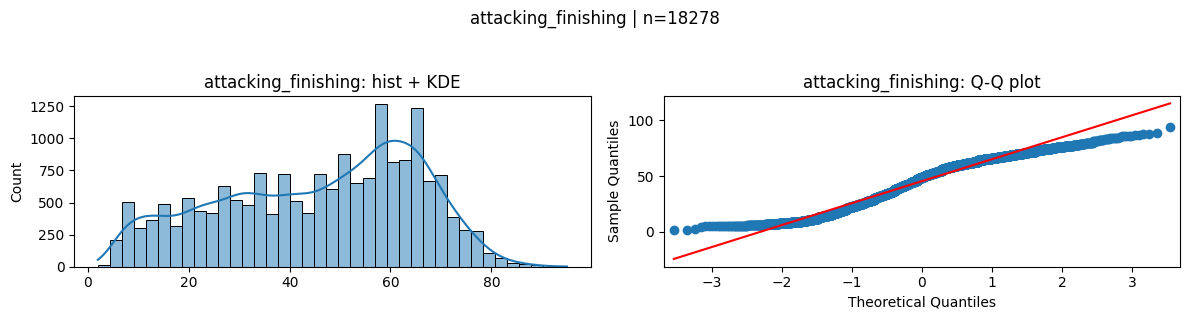

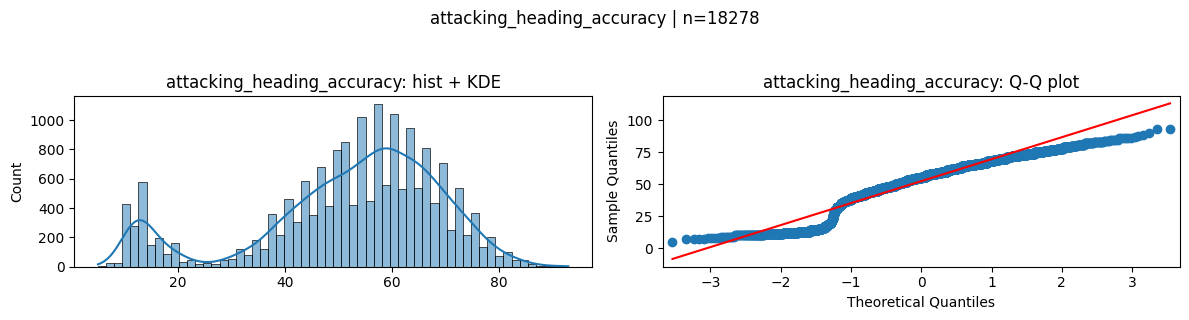

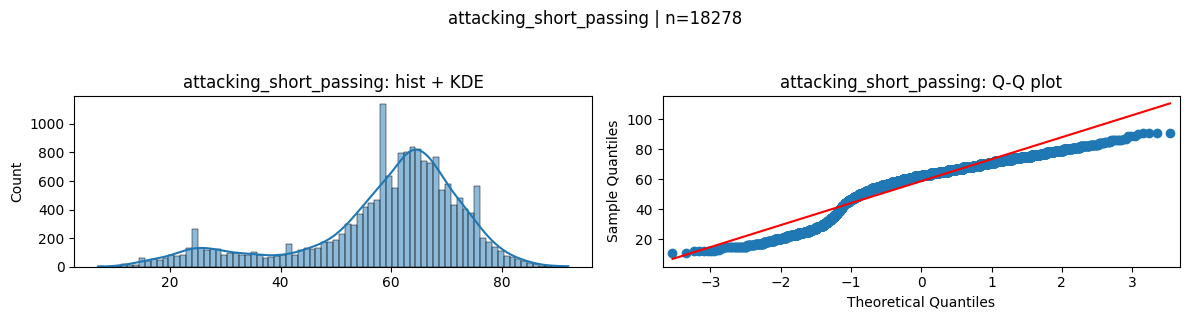

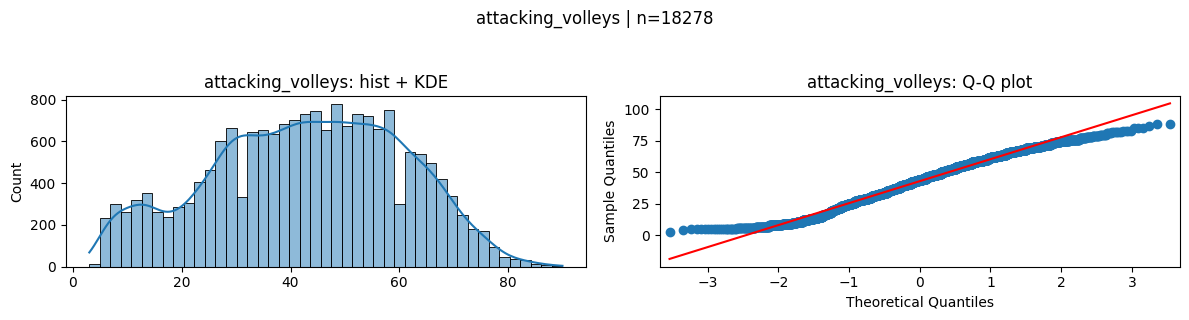

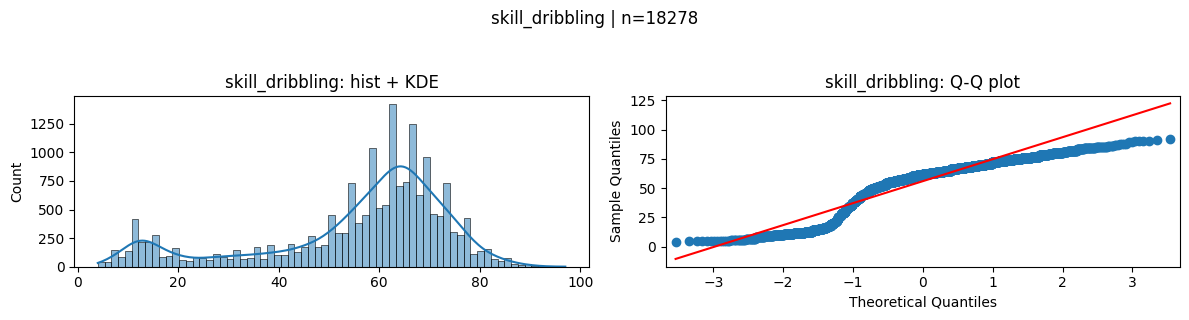

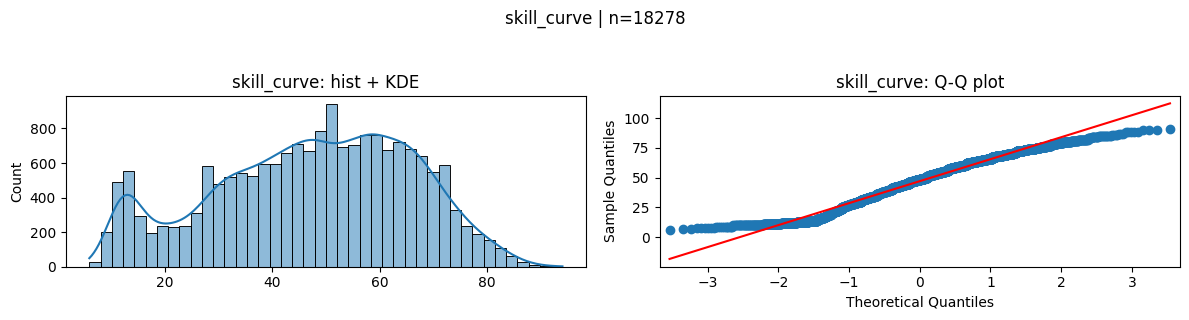

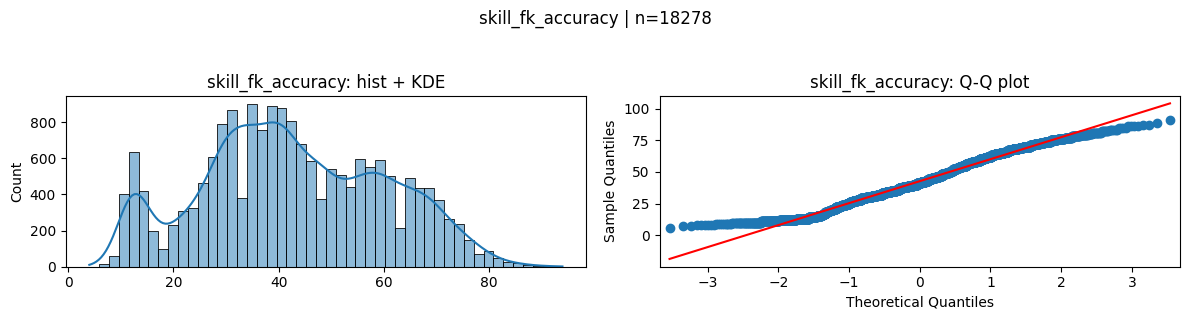

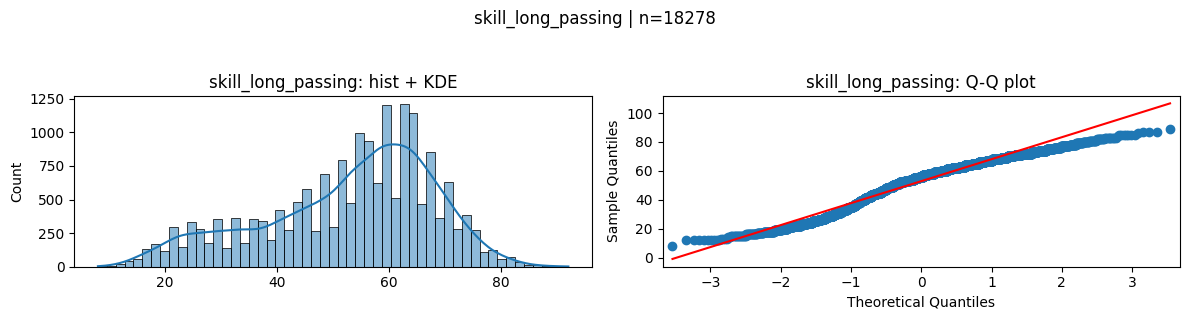

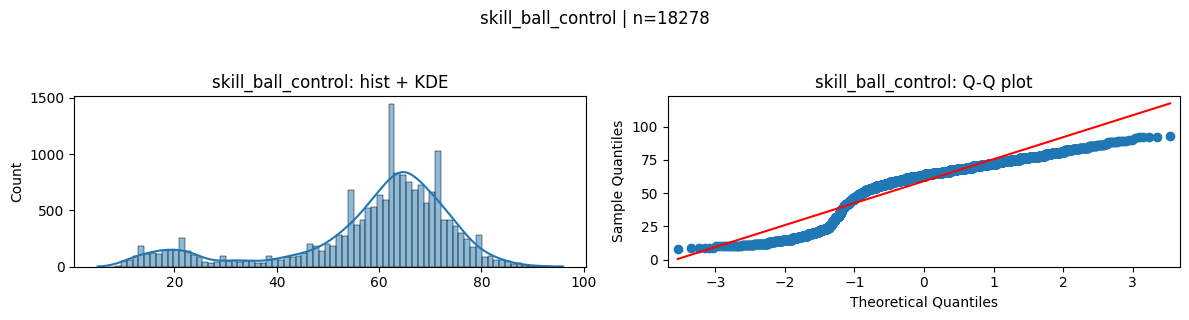

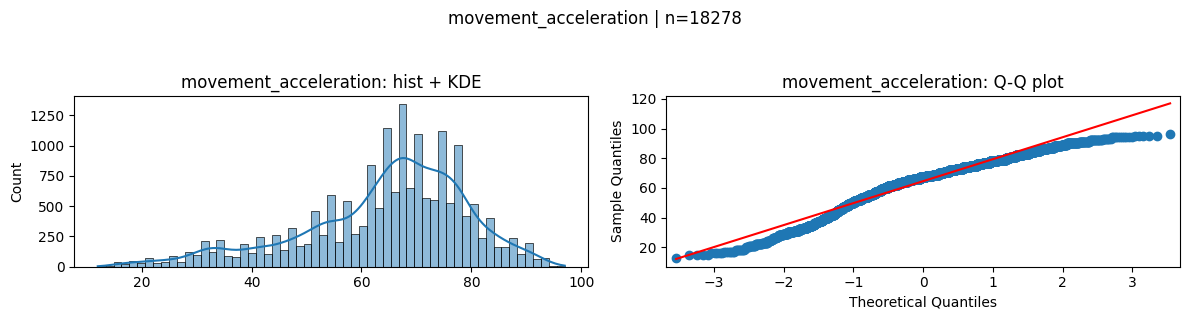

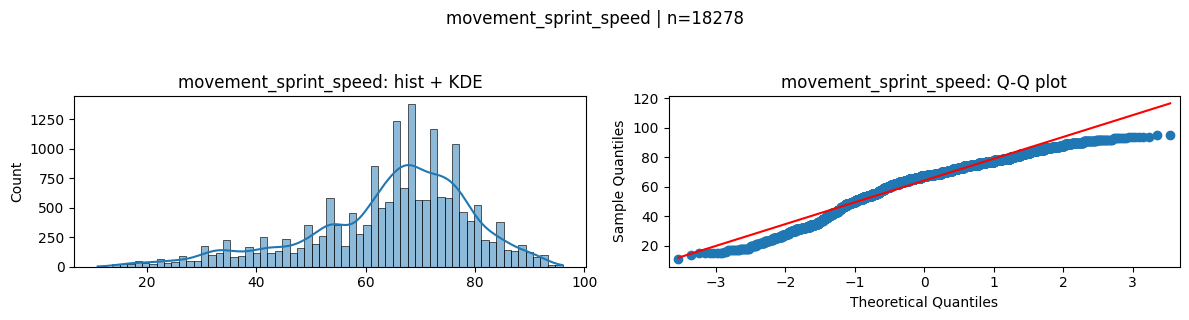

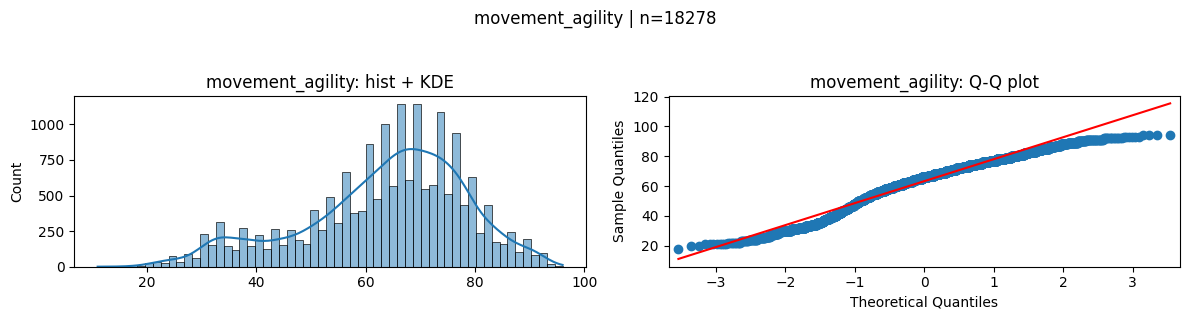

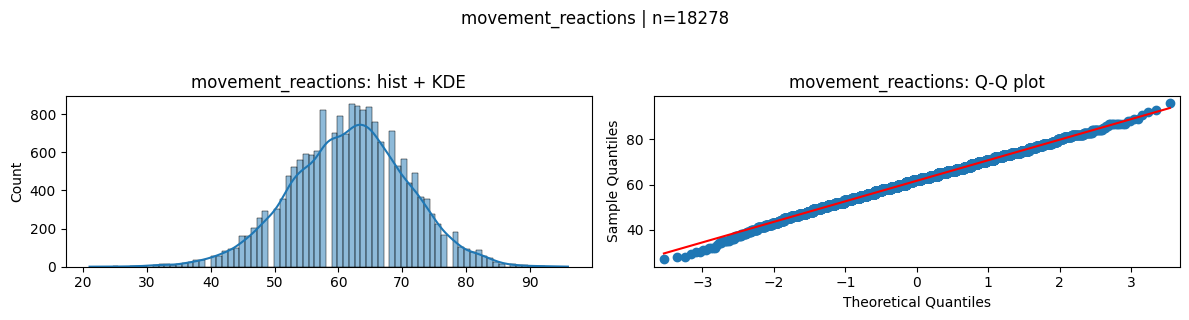

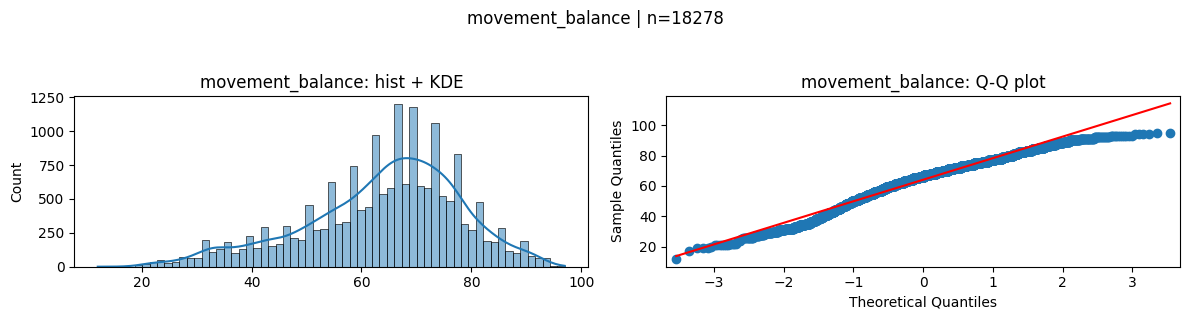

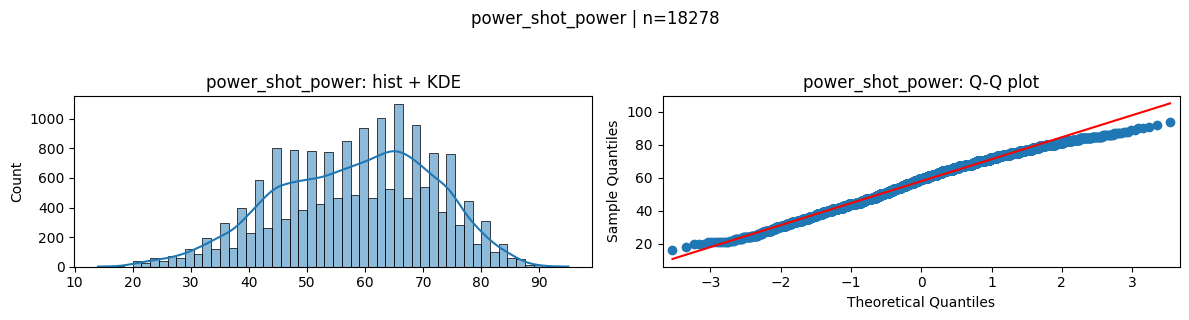

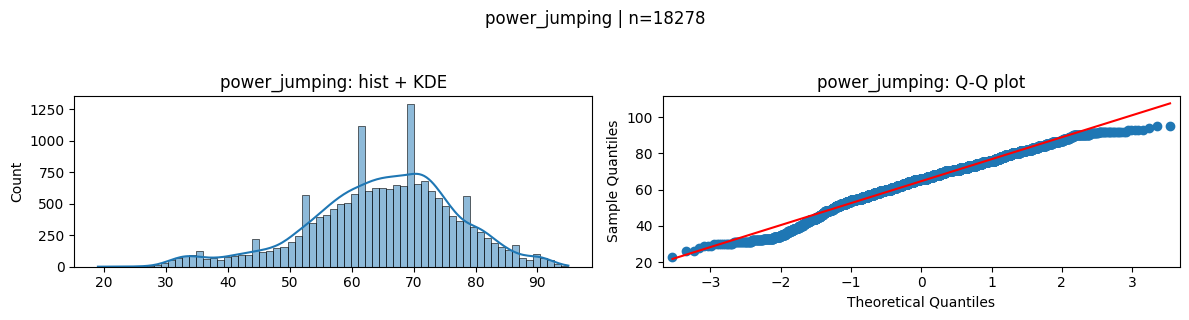

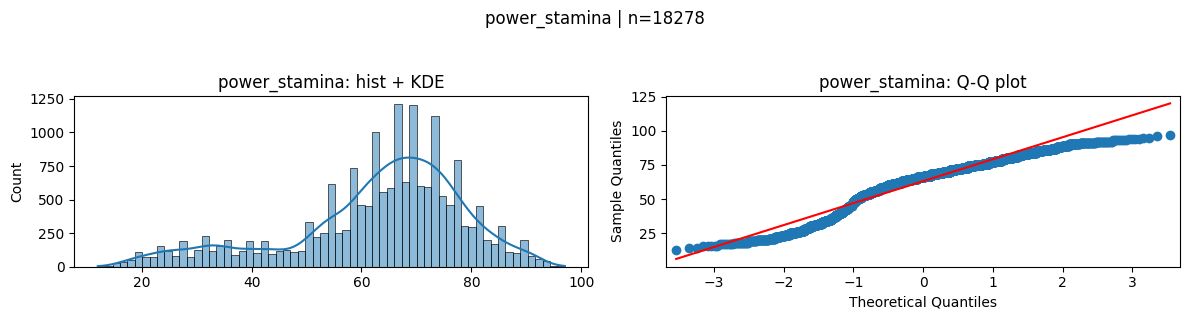

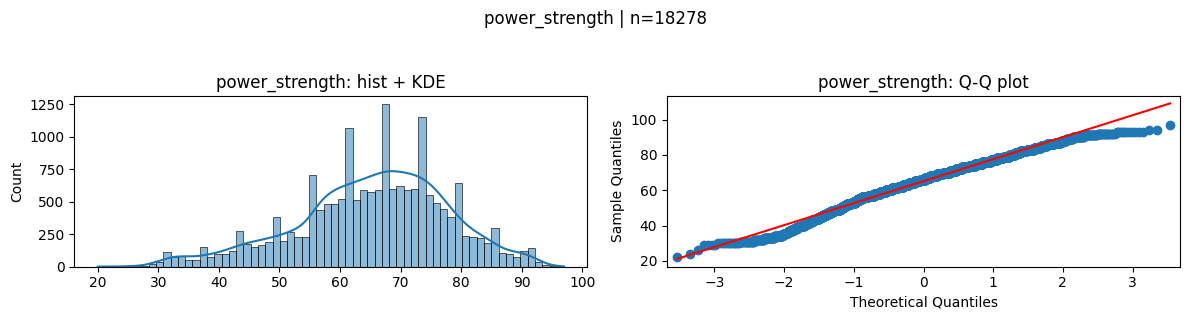

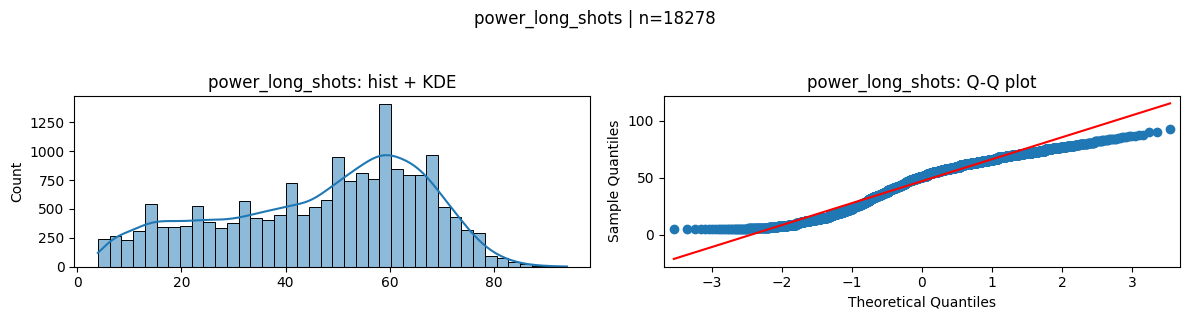

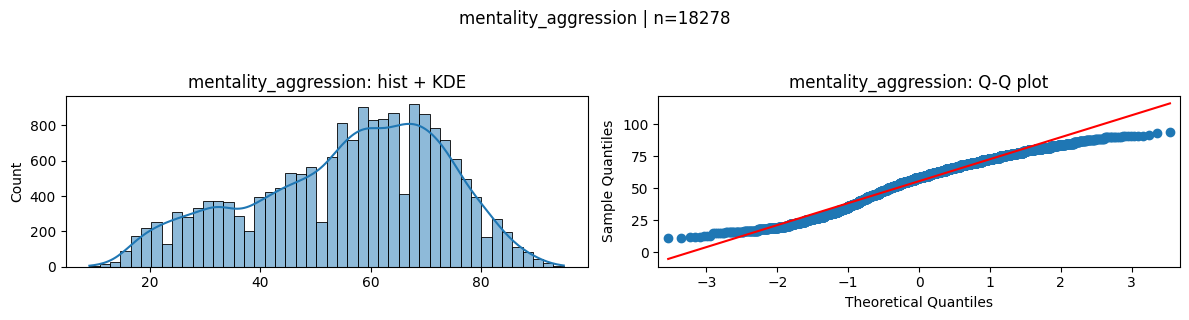

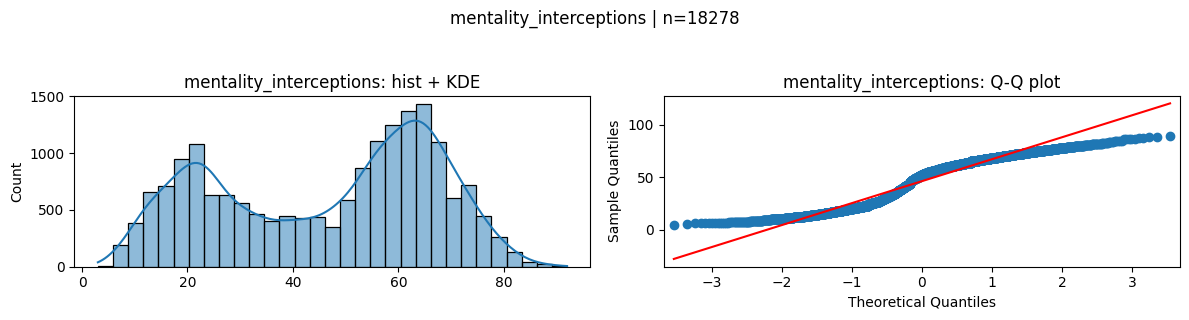

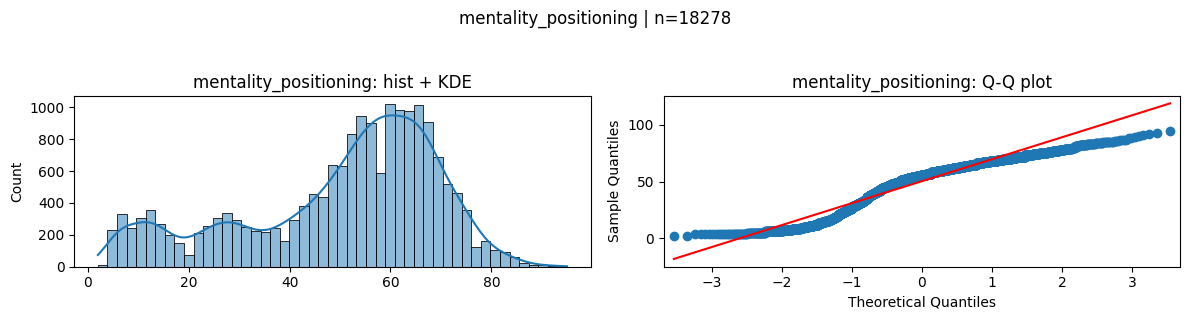

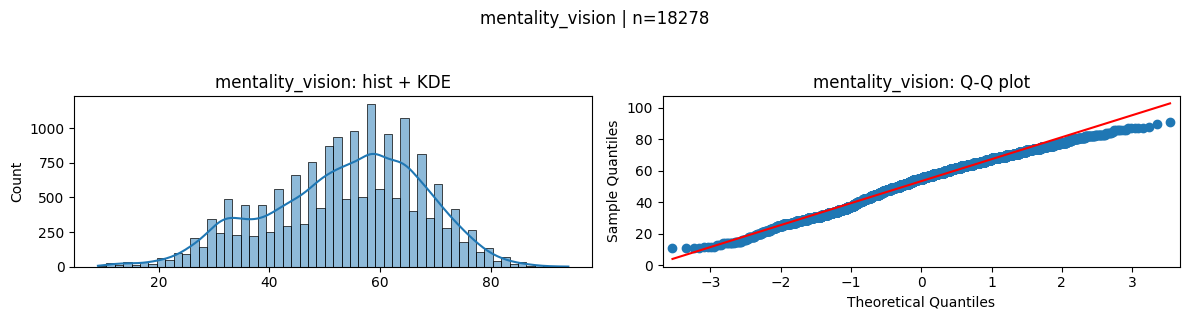

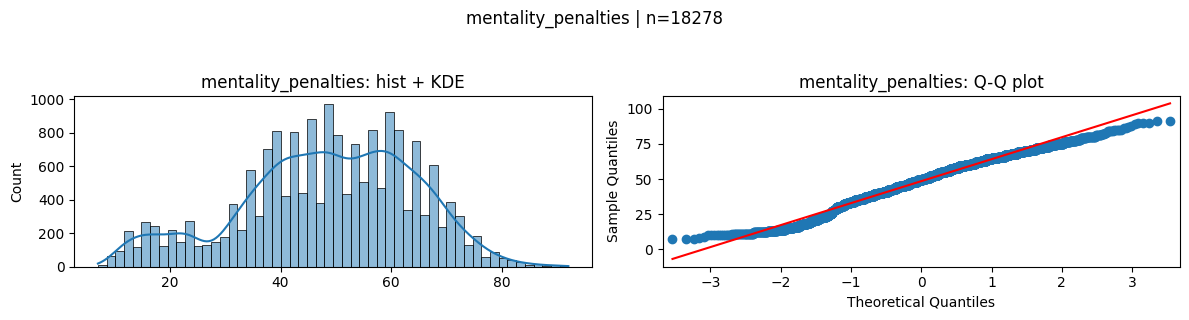

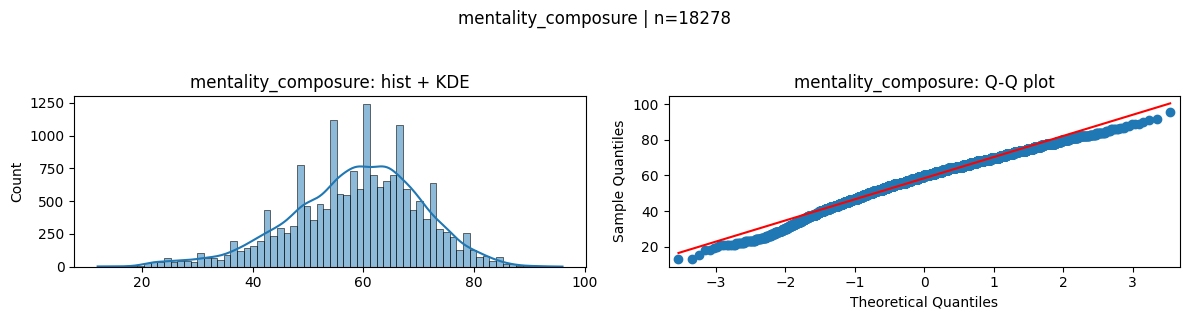

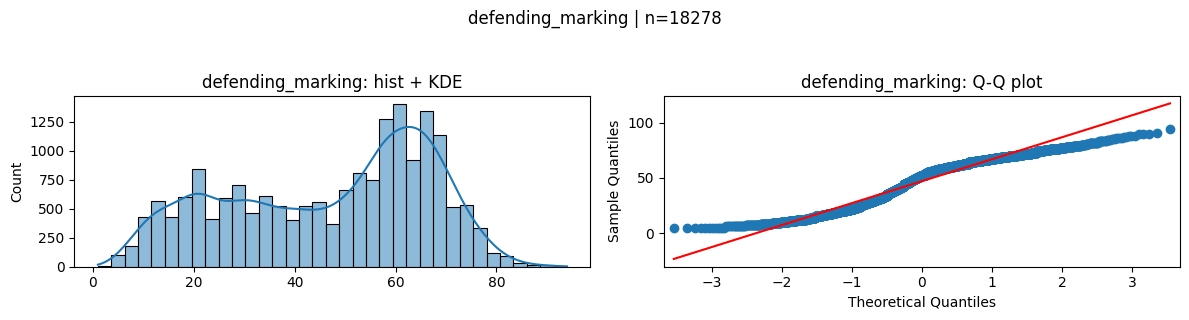

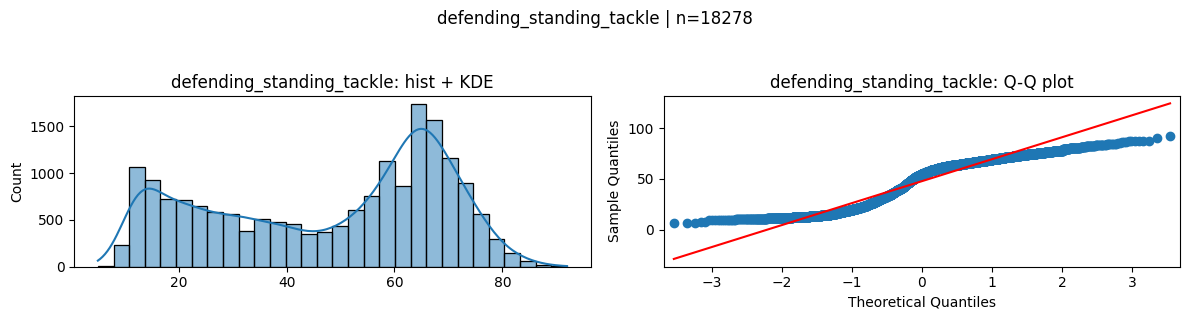

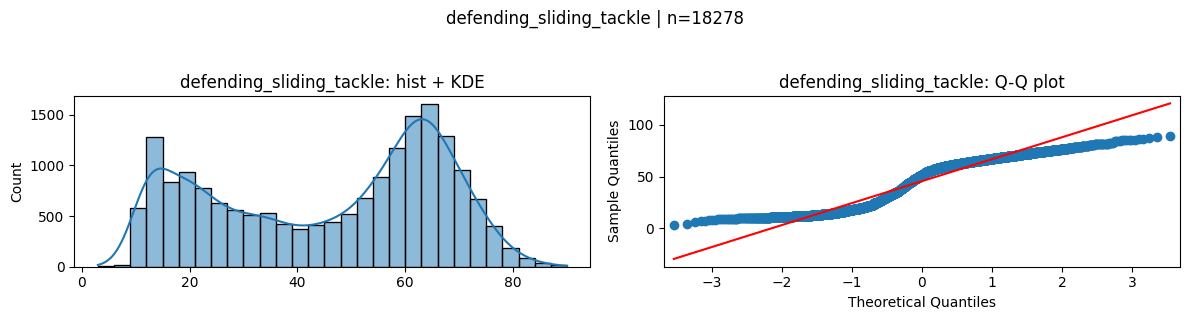

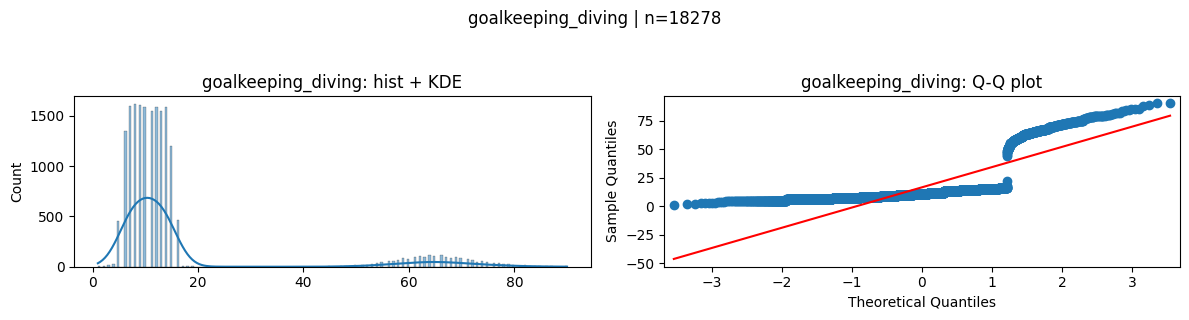

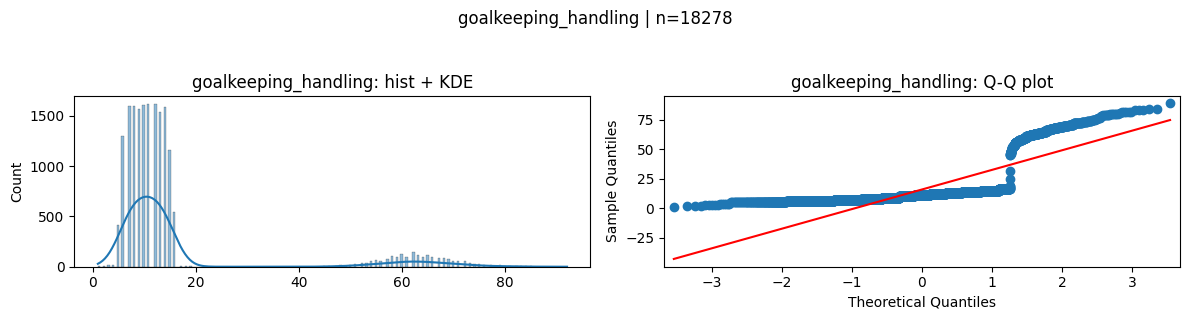

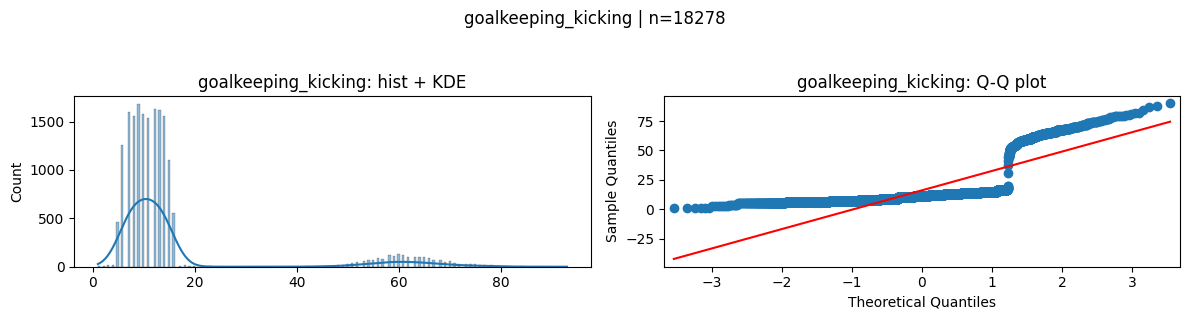

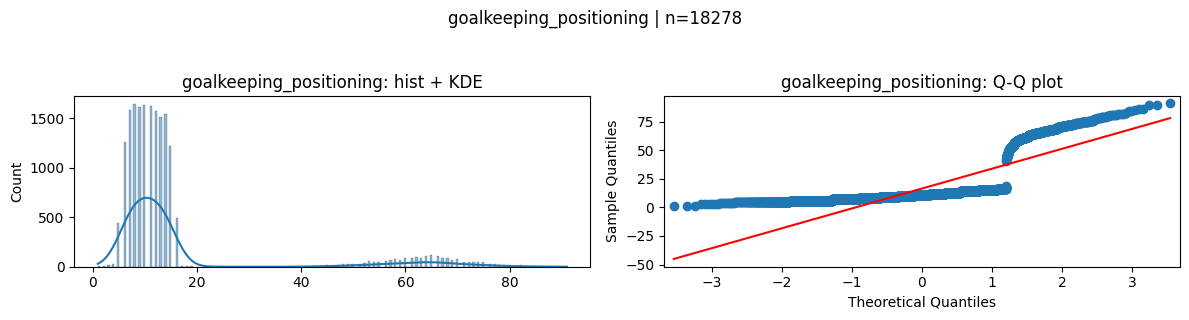

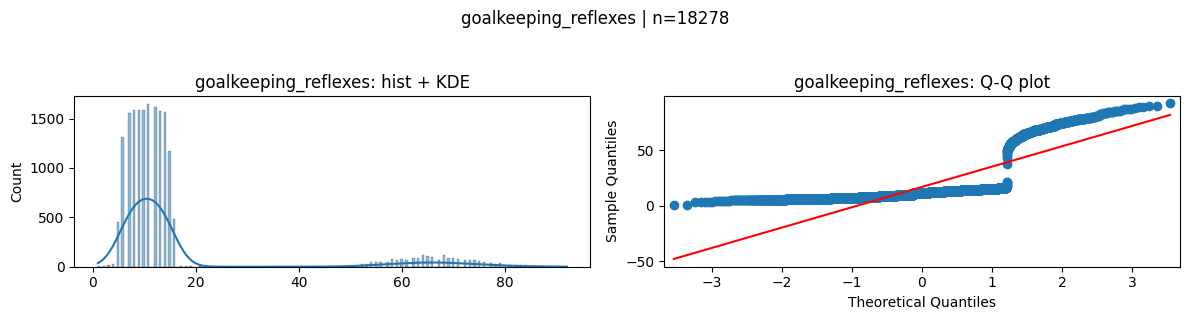

In [12]:
def analyze_distribution(series: pd.Series, name: str, max_n=5000):
    x = series.dropna().values
    if len(x) == 0:
        return

    if len(x) > max_n:
        x_test = np.random.choice(x, size=max_n, replace=False)
    else:
        x_test = x

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    sns.histplot(x, kde=True, ax=axes[0])
    axes[0].set_title(f"{name}: hist + KDE")

    sm.qqplot(x_test, line="s", ax=axes[1])
    axes[1].set_title(f"{name}: Q-Q plot")

    fig.suptitle(f"{name} | n={len(x)}", y=1.05, fontsize=12)
    plt.tight_layout()
    plt.show()

num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    analyze_distribution(df[col], col)

From the histograms and qq-plots of the features, it can be seen that most features have a normal or near-normal distribution. There are some interesting features related to the features of goalkeepers, for example: goalkeeper_reflexes. Their distribution seems to have two graphs (both normally distributed). The left one has a larger number of observations, but they are smaller in value. This is due to the fact that these are actually the values for field players who are not goalkeepers, so they have small values for this features, but there are more of them than goalkeepers in the dataset.

## Outliers

As I mentioned earlier in my previous work, in such a well-designed game (FIFA 20) and from such a major developer (EA Sports), there should hardly be any anomalies in their data. However, in this work, we previously noticed a suspicious value related to potential and age. Let's build a graph of the dependence of overall and potential for players over 39.

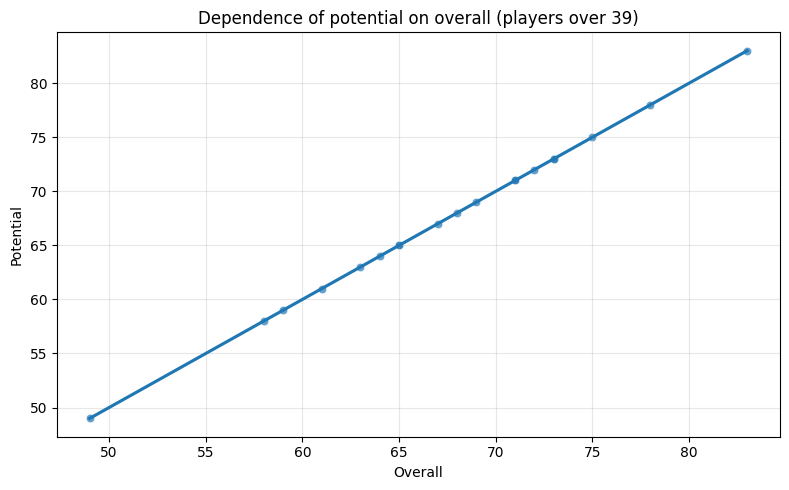

,short_name,age,overall,potential
200,G. Buffon,41,83,83
868,Hilton,41,78,78
1880,C. Pizarro,40,75,75
2963,D. Dainelli,40,73,73
2965,Cifuentes,40,73,73
3706,C. Lucchetti,41,72,72
4417,N. Rimando,40,71,71
4418,T. Howard,40,71,71
6235,J. Gillet,40,69,69
7230,Lee Dong Gook,40,68,68


In [13]:
df_39 = df.loc[(df["age"] > 39), ["age", "overall", "potential"]].dropna()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_39, x="overall", y="potential", alpha=0.7)
sns.regplot(data=df_39, x="overall", y="potential", scatter=False)  # линия тренда
plt.title("Dependence of potential on overall (players over 39)")
plt.xlabel("Overall")
plt.ylabel("Potential")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df[df['age'] > 39][['short_name', 'age', 'overall', 'potential']]

We have obtained a linear graph. As you can see, these are not outliers; these players simply have a fairly high overall rating to begin with, and since potential cannot be negative relative to the current rating and there are few players aged 41, their average potential turned out to be high. It essentially reflects the average rating of these players.

In previous and current work, I was unable to detect outliers, but ‘strange’ values were found in the body_type attribute.

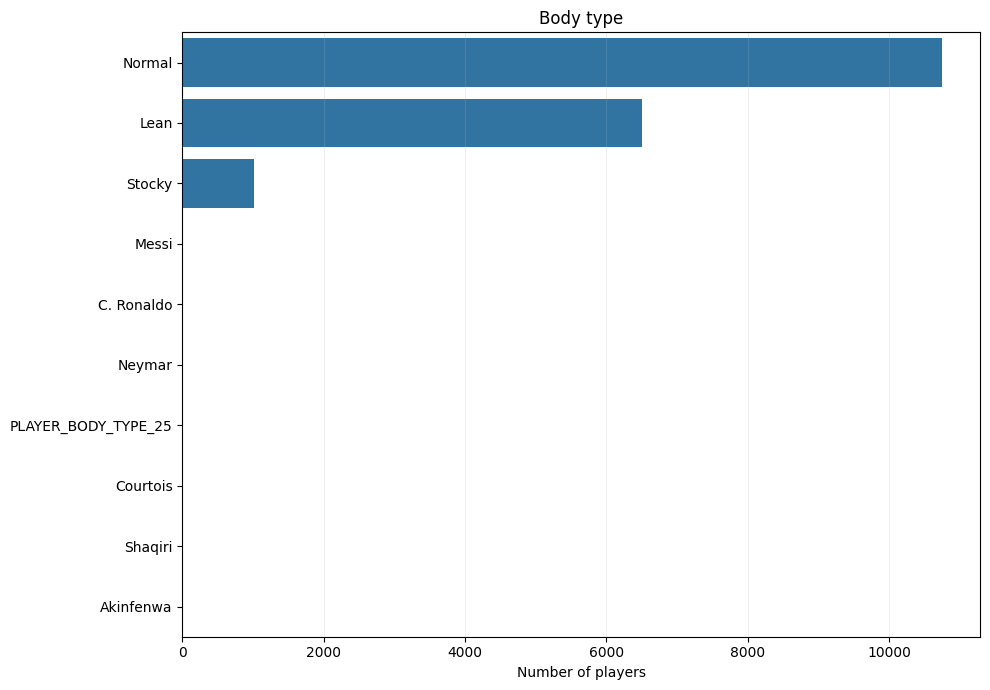

In [14]:
vc = df["body_type"].value_counts(dropna=True)

top_k = 25
top = vc.head(top_k)
other = vc.iloc[top_k:].sum()
if other > 0:
    top.loc["Other"] = other

plt.figure(figsize=(10, 7))
sns.barplot(x=top.values, y=top.index.astype(str))
plt.title("Body type")
plt.xlabel("Number of players")
plt.ylabel("")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

Strange values are observed, such as Messi, C. Ronaldo, Neymar, PLAYER_BODY_TYPE_25, etc.

## NaN-values

<Axes: title={'center': 'Distribution of NaN-values'}>

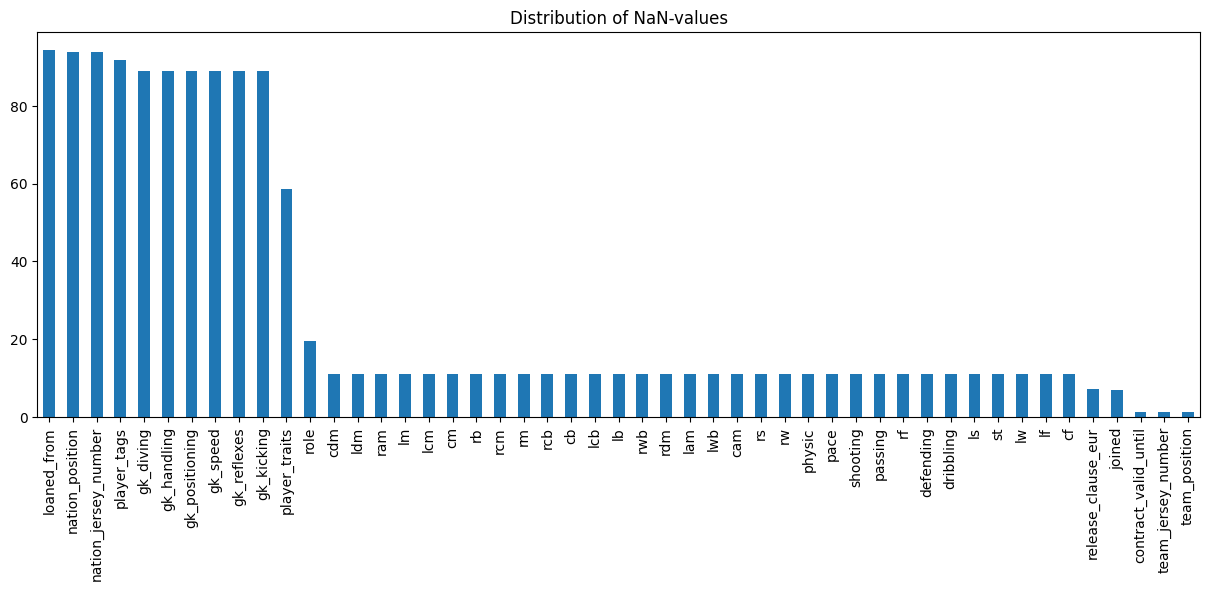

In [15]:
cols_null_percent = df.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)

cols_with_null.plot(
    kind='bar',
    figsize=(15, 5),
    title='Distribution of NaN-values'
)

Let's analyse Nan-values based on several features. loaned_from indicates which club the player is on loan from; otherwise, it is NaN-value (the player belongs to the current club). Since most players are not on loan, this characteristic has a large number of NaN-values. gk_* - these are various features of goalkeepers, since most players are field players, these features have empty values. nation_jersey_number and nation_position - the jersey number in the national team and the player's position in the national team, respectively. National teams have a limited number of players, so most players do not make it there, as the best players in their country are selected. Consequently, these features are empty for players who did not make it to their national team. It is safe to say that NaN-values are due to their own reasons. 

# Regression analysis

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Linear regression: *overall* - target, *passing* - dependent.

In [17]:
tmp = df[["overall", "passing"]].copy()
tmp["overall"] = pd.to_numeric(tmp["overall"], errors="coerce")
tmp["passing"] = pd.to_numeric(tmp["passing"], errors="coerce")
tmp = tmp.dropna()

X = tmp[["passing"]]
y = tmp["overall"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

# Metrics
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metrics = {
    "R2_train": r2_score(y_train, y_pred_train),
    "R2_test": r2_score(y_test, y_pred_test),
    "MAE_test": mean_absolute_error(y_test, y_pred_test),
    "RMSE_test": rmse(y_test, y_pred_test),
    "coef": lr.coef_[0],
    "intercept": lr.intercept_
}

print("Linear regression: overall = coef*passing + intercept")
for k, v in metrics.items():
    print(f"{k:>10}: {v:.4f}" if isinstance(v, float) else f"{k:>10}: {v}")


Linear regression: overall = coef*passing + intercept
  R2_train: 0.4659
   R2_test: 0.4754
  MAE_test: 3.8745
 RMSE_test: 4.9496
      coef: 0.4489
 intercept: 40.7451


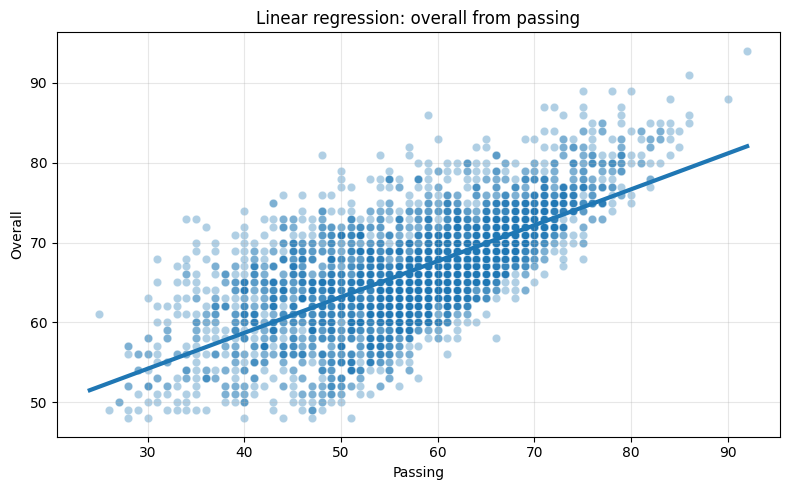

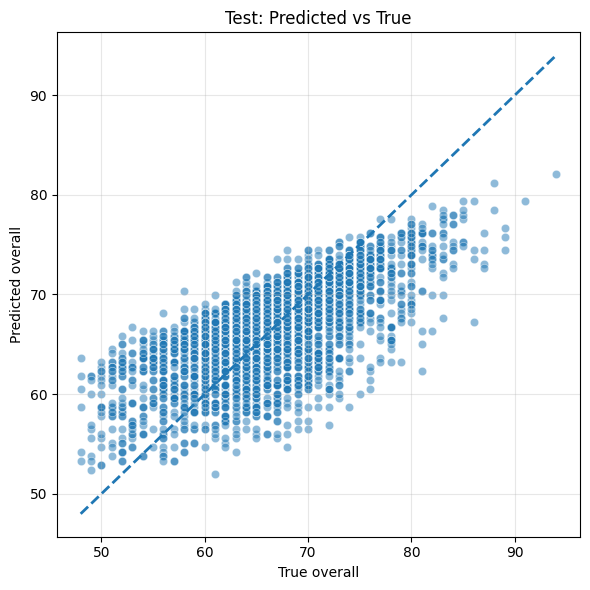

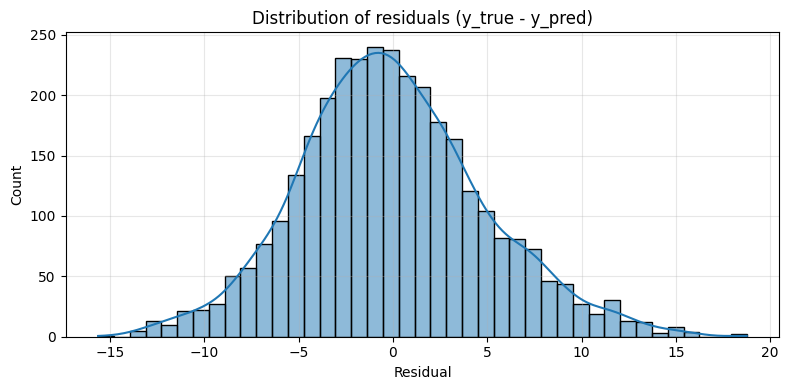

In [18]:
# Visualisation of regression results (scatter + line)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tmp.sample(min(len(tmp), 4000), random_state=42), x="passing", y="overall", alpha=0.35)

x_line = np.linspace(tmp["passing"].min(), tmp["passing"].max(), 200)
y_line = lr.predict(pd.DataFrame({"passing": x_line}))
plt.plot(x_line, y_line, linewidth=3)

plt.title("Linear regression: overall from passing")
plt.xlabel("Passing")
plt.ylabel("Overall")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#  predicted vs true (на test)
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, linestyle="--", linewidth=2)  # line y=x
plt.title("Test: Predicted vs True")
plt.xlabel("True overall")
plt.ylabel("Predicted overall")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

residuals = y_test - y_pred_test

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of residuals (y_true - y_pred)")
plt.xlabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



We obtained a very good result, considering that we predict the target variable using a single dependent variable. The metrics tell us that, on average, the model is off by 4 points, and sometimes (due to outliers/extreme cases) the errors are closer to 5 (MAE_test: 3.8745 RMSE_test: 4.9496). Passing explains only about 47–48% of the overall variation (R2_test: 0.4754). That is, the connection is noticeable, but one feature is not enough to accurately predict the overall rating.

### Outliers

In [19]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

In [20]:
tmp = df[["overall", "passing"]].copy()
tmp["overall"] = pd.to_numeric(tmp["overall"], errors="coerce")
tmp["passing"] = pd.to_numeric(tmp["passing"], errors="coerce")
tmp = tmp.dropna().reset_index(drop=False).rename(columns={"index": "row_id"})

X = sm.add_constant(tmp["passing"])
y = tmp["overall"]

model = sm.OLS(y, X).fit()
infl = OLSInfluence(model)

# Impact metrics
tmp["fitted"] = model.fittedvalues
tmp["resid"] = model.resid

tmp["leverage"] = infl.hat_matrix_diag                       
tmp["stud_resid"] = infl.resid_studentized_external          
tmp["cooks_d"] = infl.cooks_distance[0]                      
tmp["dffits"] = infl.dffits[0]                               

n = len(tmp)
p = int(model.df_model) + 1 

# Threshold values
lev_thr = 2 * p / n
stud_thr = 3
cooks_thr = 4 / n
dffits_thr = 2 * np.sqrt(p / n)

tmp["is_outlier"] = tmp["stud_resid"].abs() > stud_thr
tmp["is_high_leverage"] = tmp["leverage"] > lev_thr
tmp["is_influential"] = (tmp["cooks_d"] > cooks_thr) | (tmp["dffits"].abs() > dffits_thr)


cols_show = ["row_id", "overall", "passing", "stud_resid", "leverage", "cooks_d", "dffits",
             "is_outlier", "is_high_leverage", "is_influential"]

top_infl = tmp.sort_values(["cooks_d", "leverage", "stud_resid"], ascending=False).head(15)[cols_show]
display(top_infl)

print("Num of outliers:", int(tmp["is_outlier"].sum()))
print("Num of observations with a high leverage:", int(tmp["is_high_leverage"].sum()))
print("Num of influential observations:", int(tmp["is_influential"].sum()))

,row_id,overall,passing,stud_resid,leverage,cooks_d,dffits,is_outlier,is_high_leverage,is_influential
75,90,85,42.0,5.097434,0.000193,0.002510,0.070911,True,False,True
0,0,94,92.0,2.393396,0.000749,0.002145,0.065509,False,True,True
2715,3013,73,34.0,3.411428,0.000368,0.002143,0.065491,True,True,True
1045,1169,77,38.0,3.852859,0.000272,0.002017,0.063534,True,True,True
1,1,93,82.0,3.094041,0.000410,0.001963,0.062679,True,True,True
2876,3189,73,35.0,3.321200,0.000343,0.001889,0.061481,True,True,True
2004,2219,74,36.0,3.431542,0.000318,0.001871,0.061189,True,True,True
2,2,92,87.0,2.442940,0.000565,0.001687,0.058095,False,True,True
3936,4330,71,34.0,3.010325,0.000368,0.001669,0.057790,True,True,True
3338,3685,72,35.0,3.120650,0.000343,0.001668,0.057768,True,True,True


Num of outliers: 72
Num of observations with a high leverage: 1410
Num of influential observations: 942


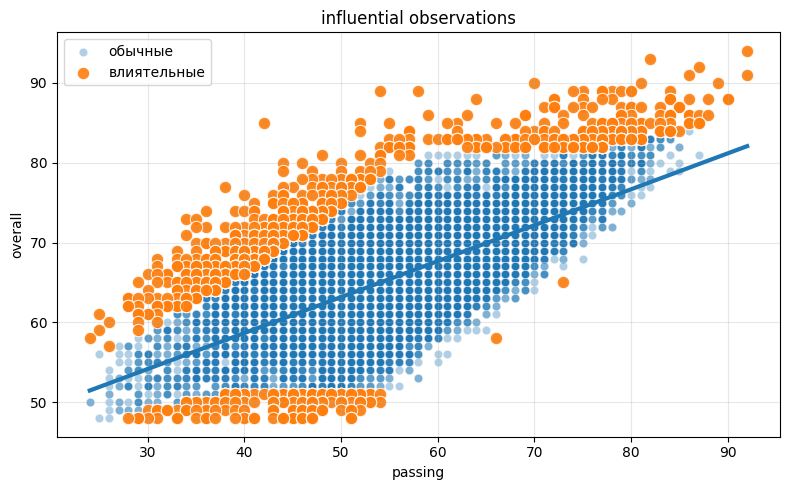

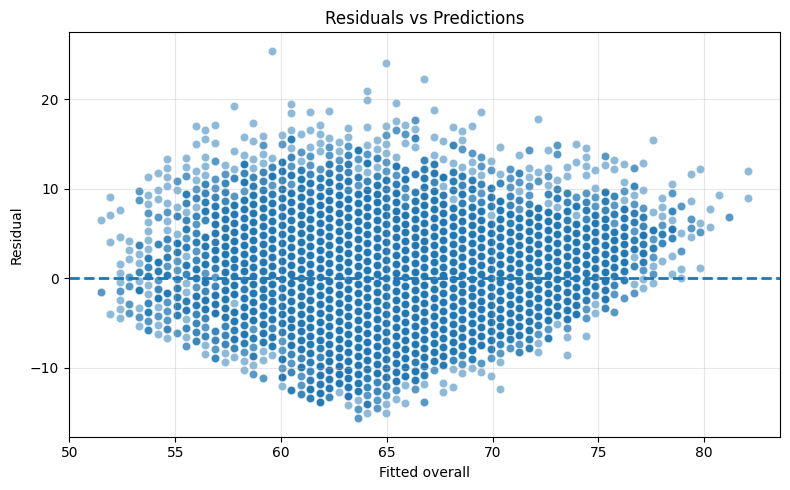

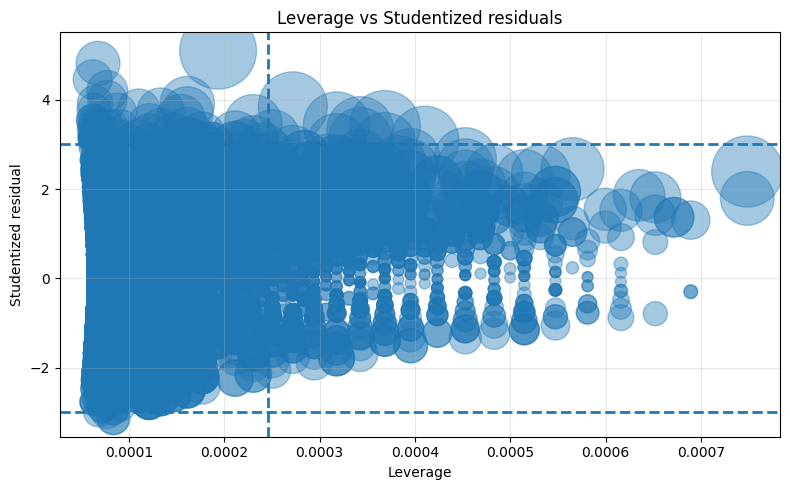

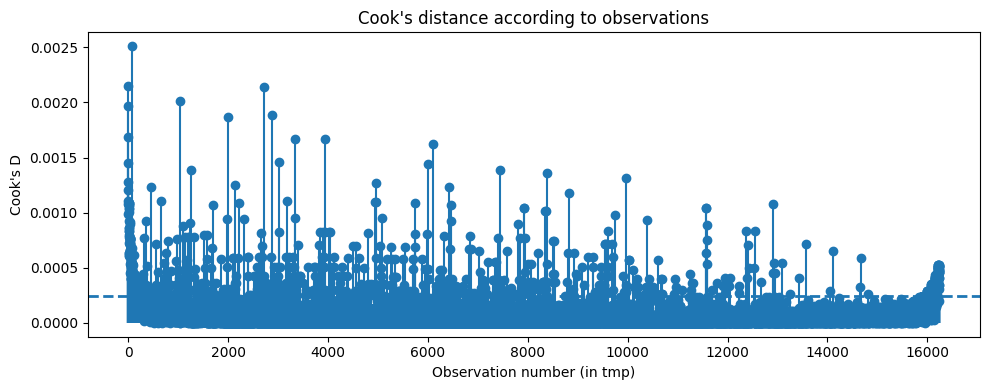

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tmp, x="passing", y="overall", alpha=0.35, label="обычные")
sns.scatterplot(data=tmp[tmp["is_influential"]], x="passing", y="overall",
                alpha=0.9, s=80, label="влиятельные")
# regression line
x_line = np.linspace(tmp["passing"].min(), tmp["passing"].max(), 200)
y_line = model.predict(sm.add_constant(x_line))
plt.plot(x_line, y_line, linewidth=3)

plt.title("influential observations")
plt.xlabel("passing")
plt.ylabel("overall")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals vs Fitted (emissions will be far from zero)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=tmp["fitted"], y=tmp["resid"], alpha=0.5)
plt.axhline(0, linestyle="--", linewidth=2)
plt.title("Residuals vs Predictions")
plt.xlabel("Fitted overall")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Leverage vs Studentized Residuals (bubble = influential observations)
plt.figure(figsize=(8, 5))
sizes = 3000 * (tmp["cooks_d"] / (tmp["cooks_d"].max() if tmp["cooks_d"].max() > 0 else 1) + 0.02)
plt.scatter(tmp["leverage"], tmp["stud_resid"], s=sizes, alpha=0.4)
plt.axvline(lev_thr, linestyle="--", linewidth=2)
plt.axhline(stud_thr, linestyle="--", linewidth=2)
plt.axhline(-stud_thr, linestyle="--", linewidth=2)
plt.title("Leverage vs Studentized residuals")
plt.xlabel("Leverage")
plt.ylabel("Studentized residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4.4 Cook's distance (stem-graph)
plt.figure(figsize=(10, 4))
plt.stem(np.arange(n), tmp["cooks_d"], basefmt=" ")
plt.axhline(cooks_thr, linestyle="--", linewidth=2)
plt.title("Cook's distance according to observations")
plt.xlabel("Observation number (in tmp)")
plt.ylabel("Cook's D")
plt.tight_layout()
plt.show()

## Linear regression: *overall* - target, *pace*, *shooting*, *passing*, *dribbling*, *defending*, *physic* - dependent.

In [22]:
features = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
target = "overall"

tmp = df[[target] + features].copy()

tmp = tmp.dropna()

X = tmp[features]
y = tmp[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Модель
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

rmse = lambda yt, yp: np.sqrt(mean_squared_error(yt, yp))

print("Multiple linear regression: overall ~ pace + shooting + passing + dribbling + defending + physic")
print(f"R2_train: {r2_score(y_train, y_pred_train):.4f}")
print(f"R2_test : {r2_score(y_test,  y_pred_test ):.4f}")
print(f"MAE_test: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE_test: {rmse(y_test, y_pred_test):.4f}")
print("\Coeffs:")
coef_table = pd.DataFrame({"feature": features, "coef": lr.coef_}).sort_values("coef", ascending=False)
display(coef_table)
print(f"Intercept: {lr.intercept_:.4f}")


Multiple linear regression: overall ~ pace + shooting + passing + dribbling + defending + physic
R2_train: 0.7116
R2_test : 0.7105
MAE_test: 2.9581
RMSE_test: 3.6772
\Coeffs:


<>:29: SyntaxWarning:

invalid escape sequence '\C'

<>:29: SyntaxWarning:

invalid escape sequence '\C'

C:\Users\user\AppData\Local\Temp\ipykernel_17480\572964975.py:29: SyntaxWarning:

invalid escape sequence '\C'



,feature,coef
3,dribbling,0.273356
5,physic,0.252426
4,defending,0.117355
1,shooting,0.113718
2,passing,0.071444
0,pace,-0.015563


Intercept: 17.9341


As expected, multiple linear regression performed significantly better than single linear regression. On average, the model has an error of 3-4 points (MAE_test: 2.9581, RMSE_test: 3.6772). The dependent features explain about 71% of the overall variation (R2_test: 0.7105).

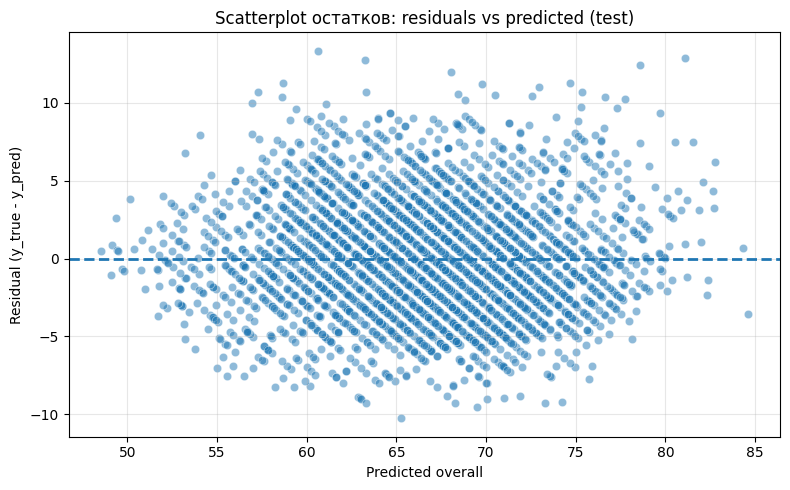

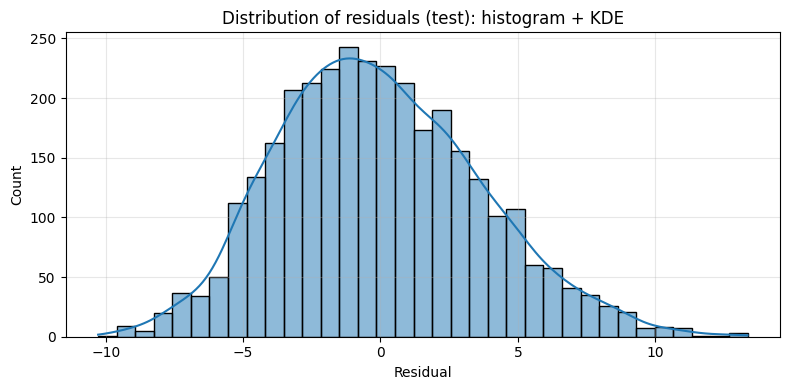

<Figure size 600x600 with 0 Axes>

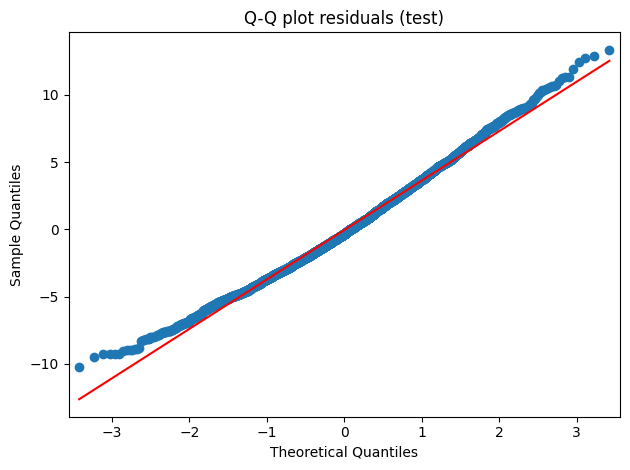

In [23]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.5)
plt.axhline(0, linestyle="--", linewidth=2)
plt.title("Scatterplot остатков: residuals vs predicted (test)")
plt.xlabel("Predicted overall")
plt.ylabel("Residual (y_true - y_pred)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Checking the normality of residuals 

# Histogram + KDE
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of residuals (test): histogram + KDE")
plt.xlabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Q-Q plot
plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line="s")
plt.title("Q-Q plot residuals (test)")
plt.tight_layout()
plt.show()


The distribution of residuals can confidently be said to be normal.

### Eliminate outliers and retrain

In [24]:
features = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
target = "overall"

tmp = df[[target] + features].copy()
for c in [target] + features:
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce")
tmp = tmp.dropna().reset_index(drop=False).rename(columns={"index": "row_id"})

X = tmp[features]
y = tmp[target]

X_sm = sm.add_constant(X)
ols = sm.OLS(y, X_sm).fit()
infl = ols.get_influence()

leverage = infl.hat_matrix_diag
stud_resid = infl.resid_studentized_external
cooks_d = infl.cooks_distance[0]

n = len(tmp)
p = X_sm.shape[1]  

# Thresholds
lev_thr = 2 * p / n
stud_thr = 3
cooks_thr = 4 / n

bad_mask = (np.abs(stud_resid) > stud_thr) | (leverage > lev_thr) | (cooks_d > cooks_thr)

tmp_bad = tmp.loc[bad_mask, ["row_id", target] + features].copy()

print(f"\nНайдено 'плохих' точек: {bad_mask.sum()} из {n} ({bad_mask.mean()*100:.2f}%)")
display(tmp_bad.head(15))

# Removing bad points
tmp_clean = tmp.loc[~bad_mask].copy()

X_clean = tmp_clean[features]
y_clean = tmp_clean[target]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

lr.fit(Xc_train, yc_train)

y_pred_train = lr.predict(Xc_train)
y_pred_test = lr.predict(Xc_test)

rmse = lambda yt, yp: np.sqrt(mean_squared_error(yt, yp))

print("Multiple linear regression: overall ~ pace + shooting + passing + dribbling + defending + physic")
print(f"R2_train: {r2_score(yc_train, y_pred_train):.4f}")
print(f"R2_test : {r2_score(yc_test,  y_pred_test ):.4f}")
print(f"MAE_test: {mean_absolute_error(yc_test, y_pred_test):.4f}")
print(f"RMSE_test: {rmse(yc_test, y_pred_test):.4f}")
print("\Coeffs:")
coef_table = pd.DataFrame({"feature": features, "coef": lr.coef_}).sort_values("coef", ascending=False)
display(coef_table)
print(f"Intercept: {lr.intercept_:.4f}")

<>:57: SyntaxWarning:

invalid escape sequence '\C'

<>:57: SyntaxWarning:

invalid escape sequence '\C'

C:\Users\user\AppData\Local\Temp\ipykernel_17480\2107768650.py:57: SyntaxWarning:

invalid escape sequence '\C'




Найдено 'плохих' точек: 1549 из 16242 (9.54%)


,row_id,overall,pace,shooting,passing,dribbling,defending,physic
0,0,94,87.0,92.0,92.0,96.0,39.0,66.0
1,1,93,90.0,93.0,82.0,89.0,35.0,78.0
2,2,92,91.0,85.0,87.0,95.0,32.0,58.0
3,4,91,91.0,83.0,86.0,94.0,35.0,66.0
4,5,91,76.0,86.0,92.0,86.0,61.0,78.0
5,7,90,77.0,60.0,70.0,71.0,90.0,86.0
6,8,90,74.0,76.0,89.0,89.0,72.0,66.0
7,9,90,93.0,86.0,81.0,89.0,45.0,74.0
8,10,89,96.0,84.0,78.0,90.0,39.0,75.0
9,11,89,71.0,28.0,54.0,67.0,89.0,87.0


Multiple linear regression: overall ~ pace + shooting + passing + dribbling + defending + physic
R2_train: 0.7550
R2_test : 0.7613
MAE_test: 2.6108
RMSE_test: 3.1939
\Coeffs:


,feature,coef
3,dribbling,0.301961
5,physic,0.261242
1,shooting,0.097223
4,defending,0.093803
2,passing,0.065316
0,pace,-0.009620


Intercept: 17.1423


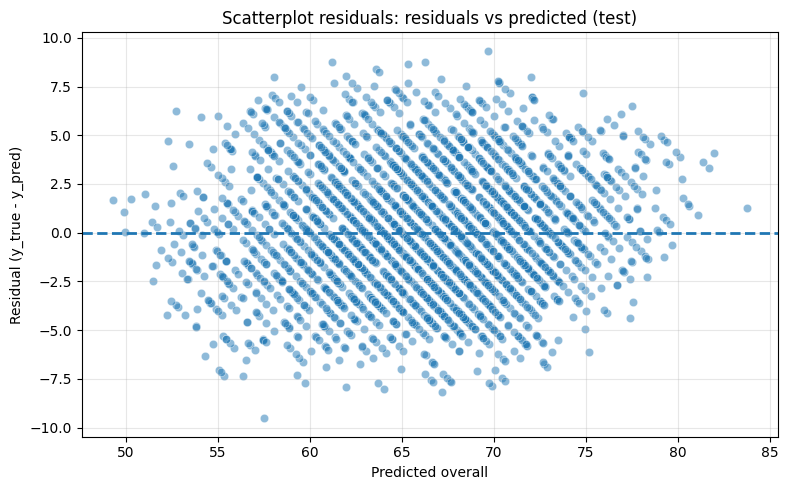

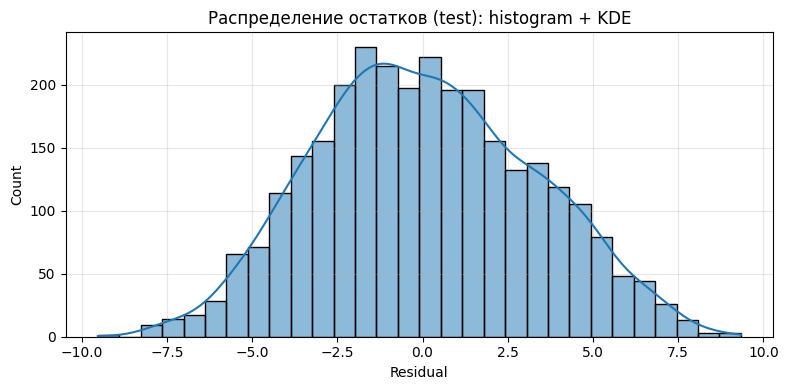

<Figure size 600x600 with 0 Axes>

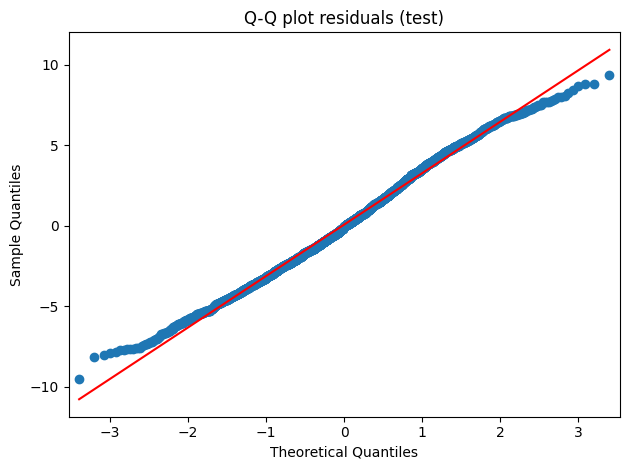

In [25]:
residuals = yc_test - y_pred_test

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.5)
plt.axhline(0, linestyle="--", linewidth=2)
plt.title("Scatterplot residuals: residuals vs predicted (test)")
plt.xlabel("Predicted overall")
plt.ylabel("Residual (y_true - y_pred)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Checking the normality of residuals

# Histogram + KDE
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Распределение остатков (test): histogram + KDE")
plt.xlabel("Residual")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Q-Q plot
plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line="s")
plt.title("Q-Q plot residuals (test)")
plt.tight_layout()
plt.show()


Outliers removal and retraining have yielded significant improvements in results, as can be seen from both the metrics and the graphs.

# Dispersion analysis

# F-test and t-test

In [26]:
features = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]
target = "overall"

tmp = df[[target] + features].copy()
for c in [target] + features:
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce")
tmp = tmp.dropna()

X = sm.add_constant(tmp[features])  
y = tmp[target]

model = sm.OLS(y, X).fit()

# Overall significance of the model (F-test)
print("Overall significance of the model (F-test)")
print(f"F-statistic: {model.fvalue:.4f}")
print(f"p-value(F):  {model.f_pvalue:.6g}")

# Significance of individual parameters (t-tests)
print("\nSignificance of coefficients (t-tests)")
coef_table = pd.DataFrame({
    "coef": model.params,
    "p_value": model.pvalues
}).drop(index="const").sort_values("p_value")

display(coef_table)

Overall significance of the model (F-test)
F-statistic: 6671.3073
p-value(F):  0

Significance of coefficients (t-tests)


,coef,p_value
physic,0.255854,0.000000e+00
dribbling,0.269295,5.632852e-290
defending,0.113098,2.816872e-253
shooting,0.112282,1.592733e-142
passing,0.074388,1.301634e-29
pace,-0.013545,5.261207e-05


F-test: p-value = 0 < 0.5, therefore we reject the null hypothesis, overall depends on the combination of parameters: pace, shooting, passing, dribbling, defending, physic.
t-test: according to t-tests, all coefficients are significant (p<0.05), i.e. each of the specified parameters makes a statistically significant contribution to explaining overall.

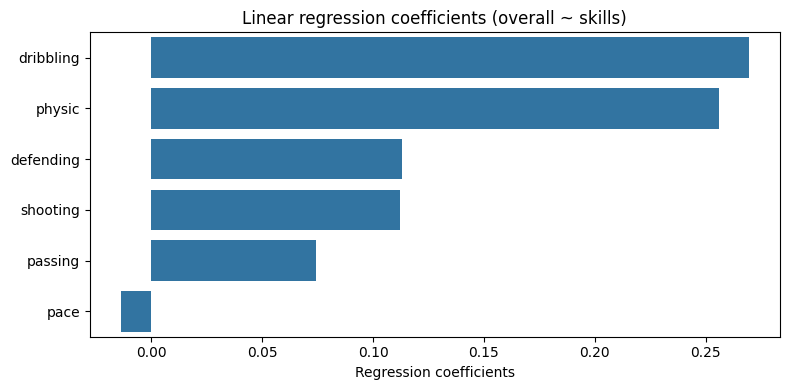

In [27]:
coef_table = pd.DataFrame({
    "feature": model.params.drop("const").index,
    "coef": model.params.drop("const").values
}).sort_values("coef", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=coef_table, x="coef", y="feature")
plt.title("Linear regression coefficients (overall ~ skills)")
plt.xlabel("Regression coefficients")
plt.ylabel("")
plt.tight_layout()
plt.show()